In [200]:
import os
import random
from datetime import datetime
from typing import List, Sequence, Tuple, Optional, Union, Callable, Literal, Dict, Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
)
from tqdm import tqdm

os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.autograd import Variable
from torch.utils import data
from torch.utils.data import ConcatDataset, DataLoader, Subset
from torch.utils.data import Dataset as TorchDataset

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps"
    if torch.backends.mps.is_available()
    else "cpu"
)


In [141]:
class Dataset(TorchDataset):
    """
    Sliding window dataset for Limit order book classification.

    Creates overlapping windows of sequential LOB snapshots for time-series
    classification tasks.
    
    Args:
        features (np.ndarray): Input features of shape (num_samples, num_features).
        labels (np.ndarray): Target labels of shape (num_samples,).
        num_features (int): Sliding window size (number of timestamps per sample).

    Raises:
        ValueError: If features and invalid or incompatible.
    """
    def __init__(self, features: np.ndarray, labels: np.ndarray, num_classes: int, seq_size: int):
        num_windows = features.shape[0] - seq_size + 1

        # Labels should match the number of windows. NOT row features
        if num_windows != labels.shape[0]:
            raise ValueError(
                f"Label count mismatch. Expected {num_windows} labels "
                f"(features={features.shape[0]} - seq_size={seq_size}), "
                f"got {labels.shape[0]}"
            )

        if seq_size < 1:
            raise ValueError("seq_size must be >= 1. Got {seq_size}")

        if features.shape[0] < seq_size:
            raise ValueError(
                "Not enough samples for seq_size={seq_size}. "
                f"Got {features.shape[0]} samples."
            )

        self.seq_size = seq_size
        self.num_features = features.shape[1]

        self._features = torch.from_numpy(features).float()
        self._labels= torch.from_numpy(labels).long()

    def __len__(self):
        return self._features.shape[0] - self.seq_size + 1

    def __getitem__(self, index: int) -> Tuple[torch.Tensor, torch.Tensor]:
        """ 
        Get a windows index.

        Args:
            index: Sample index.
        
        Returns:
            features: Tensor of shape (num_features, seq_size).
            label: Scaler label tensor for the last timestamp in the window.
        """
        # Extract window: (seq_size, num_features)
        window = self._features[index : index + self.seq_size, :]

        # Transpose to (num_features, seq_size) for Conv1d
        window = window.permute(1, 0)

        return window, self._labels[index]

In [142]:
def _load_block(path: str) -> np.ndarray:
    """
    Load dataset from text file. 
    
    Args:
        path: path to dataset text file.
    
    Returns:
        Loaded dataset as numpy array
    """
    return np.loadtxt(path)


def _make_Xy_from_block(
    data: np.ndarray, 
    horizon: int,
    seq_size: int,
    num_features: int,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Extract features (X) and labels (y) from a data block. 

    Args:
        data: Raw data array of shape (N, D) where N is rows and D is samples.
        horizon: Label horizon index. Maps to prediction windows:
            1 -> 100 ticks, 2 -> 50, 3 -> 30, 4 -> 20, 5 -> 10.
        seq_size: Sequence length for sliding window.
        num_features: Number of features rows to extract from data.

    Returns:
        X: Features array of shape (num_samples, num_features).
        y: Label array of shape (num_samples,) with values in [0, 1, 2].
    """
    # Extract labels from the horizon row, shift from (1, 2, 3). to (0, 1, 2)
    labels = data[-horizon, :].flatten()[seq_size - 1:] - 1
    
    # Extract features and transpose to (samples, features)
    features = data[:num_features, :].T

    return features, labels


def _build_concat_dataset(
    folds: Sequence[int],
    dir_path: str,
    prefix: str,
    horizon: int,
    seq_size: int,
    num_features: int,
) -> ConcatDataset:
    """
    Build a concatenated dataset from multiple fold files.
    
    Args:
        folds: List of fold indices to include.
        dir_path: Directory containing the fold files.
        prefix: Filename prefix for fold files.
        horizon: Label horizon index for prediction window.
        seq_size: Sequence length for sliding window.
        num_features: Number of features to extract.
    
    Returns:
        Concatenated dataset from all valid folds.
    
    Raises:
        ValueError: If no usable datasets are found.
    """
    datasets = []

    for fold_idx in folds:
        file_path = f"{dir_path}/{prefix}_{fold_idx}.txt"
        raw_data = _load_block(file_path)

        features, labels = _make_Xy_from_block(
            data=raw_data,
            horizon=horizon,
            seq_size=seq_size,
            num_features=num_features,
        )

        # skip folds with no valid samples
        if labels.shape[0] == 0:
            continue

        datasets.append(Dataset(features, labels, num_classes=3, seq_size=seq_size))

    if not datasets:
        raise ValueError("No usable datasets. All folds may be too short after alignment.")

    return ConcatDataset(datasets)


def _time_ordered_split(
    dataset: ConcatDataset,
    val_ratio: Optional[float],
) -> Tuple[ConcatDataset, Optional[Subset]]:
    """
    Splits dataset into train/validation sets preserving time order.

    Unlike random splitting, this maintains temporal ordering by using
    the first (1 - val_ratio) samples for training and the rest for validation.

    Args:
        dataset: Full dataset to split.
        val_ratio: Fraction of data to use for validation (0.0 to 1.0).
            If None or <= 0, no validation set is created.

    Returns:
        train_dataset: Training dataset.
        val_dataset: Validation dataset, or None if val_ratio is invalid.
    """
    if val_ratio is None or val_ratio <= 0:
        return dataset, None

    total_samples = len(dataset)
    train_size = int(total_samples * (1 - val_ratio))

    train_idx = list(range(train_size))
    val_idx = list(range(train_size, total_samples))

    return Subset(dataset, train_idx), Subset(dataset, val_idx)


def _extract_labels(dataset: ConcatDataset) -> np.ndarray:
    """
    Extract all labels from a dataset.

    Args:
        dataset: Dataset or Subset to extract labels from.

    Returns:
        Array of labels as int64.
    """
    labels = [int(dataset[i][1]) for i in range(len(dataset))]
    return np.asarray(labels, dtype=np.int64)


# Mapping from horizon to prediction window (in ticks)
HORIZON_TO_TICKS = {1: 100, 2: 50, 3: 30, 4: 20, 5: 10}


def make_loaders_for_fold(
    fold: int,
    horizon: int = 5,
    seq_size: int = 10,
    num_features: int = 144,
    batch_size: int = 128,
    train_dir: str = "../data/training",
    test_dir: str = "../data/testing",
    val_ratio: float = 0.0,
    num_folds: int = 9,
    test_horizon_folds: int = 1,
    test_folds: Optional[Sequence[int]] = None,
) -> tuple[DataLoader, DataLoader | None, DataLoader, np.ndarray]:
    """
    Create train, validation, and test data loaders for a given fold.

    Uses an expending window approach where training uses all folds up to
    and including the current fold, and testing uses subsequent folds.

    Args:
        fold: Current fold number (1-indexed)
        horizon: Label horizon index (1-5). See HORIZON_TO_TICKS for mapping.
        seq_size: Sequence length for sliding window.
        num_features: Number of LOB features to use.
        batch_size: batch size for data loaders.
        train_dir: Directory containing training fold files.
        test_dir: Directory containing test fold files.
        val_ratio: Fraction of training data to use for validation.
        num_folds: Total numbers of available folds.
        test_horizon_folds: Number of future folds to use for testing.
        test_folds: Explicit list of test fold indices. Overrides auto-selection.

    Returns:
        train_loader: DataLoader for training data.
        val_loader: DataLoader for validation data, or None if val_ratio <= 0.
        test_loader: DataLoader for test data.
        y_train: Array of training labels for class weight computation.
    
    Raises
        ValueError: If fold is out of range or train/test sets overlap.
    """
    # Validate fold number
    if not 1 <= fold <= num_folds:
        raise ValueError(f"fold must be in [1,{num_folds}], got {fold}.")

    # Define training fodls (expanding window)
    train_folds = list(range(1, fold + 1))

    # Define test folds (future folds)
    if test_folds is None:
        test_start = fold + 1
        test_end = min(fold + test_horizon_folds, num_folds)

        if test_start > num_folds:
            raise ValueError(
                "No future folds available for testing."
                f"Fold {fold} is the last available fold."
            )

        test_folds = list(range(test_start, test_end + 1))

    else:
        test_folds = list(test_folds)

    # Validate no overlap between train and test
    overlap = set(train_folds) & set(test_folds)
    if overlap:
        raise ValueError(f"Train/test overlap detected on folds: {overlap}")

    # Build datasets
    train_dataset_full = _build_concat_dataset(
        folds=train_folds,
        dir_path=train_dir,
        prefix="Train_Dst_NoAuction_ZScore_CF",
        horizon=horizon,
        seq_size=seq_size,
        num_features=num_features,
    )
    test_dataset = _build_concat_dataset(
        folds=test_folds,
        dir_path=test_dir,
        prefix="Test_Dst_NoAuction_ZScore_CF",
        horizon=horizon,
        seq_size=seq_size,
        num_features=num_features,
    )

    train_dataset, val_dataset = _time_ordered_split(train_dataset_full, val_ratio)

    # Create data loaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    val_loader = None
    if val_dataset is not None:
        val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)  

    # Extract training labels for class weight computation
    y_train = _extract_labels(train_dataset)

    return train_loader, val_loader, test_loader, y_train

In [143]:
def set_seed(seed: int = 42):
    """
    Set the seed for all random number generators.

    Args:
        seed (int): The seed to set.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

In [144]:
def compute_class_weights(
    labels: np.ndarray,
    num_classes: int = 3,
    scale: float = 1e6,
) -> torch.Tensor:
    """
    Compute inverse frequency class weights for imbalanced datasets.

    Assign higher weights to minority classes to balance their contribution
    during training. Uses formula: weight[c] = scale / count[c].
    
    Args:
        labels: Array of class labels with values in (0, num_classes).
        num_classes: Number of distinct classes.
        scale: Scaling factor for weight computation.

    Returns:
        Tensor of shape (num_classes,) with class weights on the target device.
    """
    class_counts = np.bincount(labels, minlength=num_classes)
    
    # Avoid division by zero for missing classes
    safe_counts = np.maximum(class_counts, 1)
    
    weights = scale / safe_counts

    return torch.tensor(weights, dtype=torch.float32, device=device)

In [ ]:
def train_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
) -> tuple[float, float]:
    """
    Train the model for one epoch.

    Perform forward pass, backpropagation, and optimizer step for each batch.
    Accumulates loss and accuracy metrics across all batches.
    
    Args:
        model: Neural network model to train.
        loader: DataLoader providing (features, labels) batches.
        optimizer: Optimizer for updating model parameters.
        criterion: Loss function for computing training loss.
    
    Returns:
        avg_loss: Mean loss across all batches.
        avg_accuracy: Mean accuracy across all batches.
    """
    model.train()

    total_loss = 0.0
    total_correct = 0.0
    total_samples = 0

    for features, labels in loader:
        features = features.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # Forward pass
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Accumulate metrics
        predictions = logits.argmax(dim=1)
        total_loss += loss.item() * labels.size(0)
        total_correct += (predictions == labels).sum().item()
        total_samples += labels.size(0)

    avg_loss = total_loss / total_samples
    avg_accuracy = total_correct / total_samples

    return avg_loss, avg_accuracy

In [146]:
@torch.no_grad()
def eval_epoch(
    model: nn.Module,
    loader: DataLoader,
    criterion: nn.Module,
    return_preds: bool = False,
) -> (
    tuple[float, float, float]
    | tuple[float, float, float, np.ndarray, np.ndarray]
):
    """
    Evaluate the model on a dataset.

    Compute loss, accuracy, and macro F1 score across all batches.
    Optionally return predictions for further analysis.

    Args:
        model: Neural network model to evaluate.
        loader: DataLoader providing (features, labels) batches.
        criterion: Loss function for computing evaluation loss.
        return_preds: If true, also return ground truth and predictions.

    Returns:
        avg_loss: Mean loss across all samples.
        accuracy: Classification accuracy (correct / total).
        macro_f1: Macro-averaged F1 score across all classes.
        y_true (optional): Ground truth labels if return_preds is True.
        y_pred (optional): Model predictions if return_preds is True.
    """
    model.eval()

    total_loss = 0.0
    total_samples = 0
    all_predictions: list[np.ndarray] = []
    all_labels: list[np.ndarray] = []

    for features, labels in loader:
        features = features.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # Forward pass
        logits = model(features)
        loss = criterion(logits, labels)

        # Accumulate metrics (sample-weighted)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        # Collect predictions 
        predictions = logits.argmax(dim=1)
        all_predictions.append(predictions.detach().cpu().numpy())
        all_labels.append(labels.detach().cpu().numpy())

    # Concatenate all batches
    y_pred = np.concatenate(all_predictions)
    y_true = np.concatenate(all_labels)

    # Compute metrics
    avg_loss = total_loss / max(total_samples, 1)
    accuracy = (y_pred == y_true).mean()
    macro_f1 = f1_score(y_true, y_pred, average="macro")

    if return_preds:
        return avg_loss, accuracy, macro_f1, y_true, y_pred

    return avg_loss, accuracy, macro_f1

In [147]:
class MLPBaseline(nn.Module):
    """
    Multi-Layer Perceptron baseline for LOB classification.

    A simple feed-forward network with flatten input and applies
    multiple fully-connected layers with dropout regularization.

    Args:
        num_classes: Number of ouput classes.
        num_features: Number of input features per timestep.
        seq_size: Number of timesteps in the input sequence.
        hidden_dims: Tuple of hidden layer dimensions.
        dropout: Dropout probability for regularization.

    Attributes:
        net: The feed-forward network.
    """
    def __init__(
        self,
        num_classes : int = 3,
        num_features : int = 144,
        seq_size : int = 10,
        hidden_dims : tuple[int] = (1024, 512, 256),
        dropout : float = 0.3,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.num_features = num_features
        self.seq_size = seq_size
        
        input_dim = num_features * seq_size

        layers = [nn.Flatten()]
        prev_dim = input_dim

        for i, hidden_dim in enumerate(hidden_dims):
            layers.extend([
                nn.Linear(
                    in_features=prev_dim,
                    out_features=hidden_dim,
                ),
                nn.LeakyReLU(),
                nn.Dropout(p=dropout if i < len(hidden_dims) - 1 else 0.2),
            ])
            prev_dim = hidden_dim


        # Output layer
        layers.append(
            nn.Linear(
                in_features=prev_dim,
                out_features=num_classes,
            )
        )


        self.net = nn.Sequential(*layers)


    def forward(self, x : torch.Tensor) -> torch.Tensor:
        """
        Forward pass.

        Args:
            x: Input tensor of shape (batch, num_features, seq_size).


        Returns:
            Logits tensor of shape (batch, num_classes).
        """
        return self.net(x)


    def extra_repr(self) -> str:
        """ Return a string representation of the module configuration. """
        return f"num_classes={self.num_classes}, num_features={self.num_features}, seq_size={self.seq_size}"    

In [187]:
class CNNTimeBaseline(nn.Module):
    """
    1D CNN for time-series classification.

    Uses convolutional layers for feature extraction, and fully-connected layers for classification.
    
    Args:
        num_classes (int): The number of classes in the classification task.
    
    Attributes:
        features (nn.Sequential): A sequence of convolutional layers.
        classifier (nn.Sequential): A sequence of linear layers for classification. 
    """

    def __init__(
        self,
        num_classes: int = 3,
        in_channels: int = 144,
        conv_channels: int = 128,
        classifier_dim: int = 64,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()

        self.num_classes = num_classes
        self.in_channels = in_channels
        self.conv_channels = conv_channels

        # Feature extractor: 1D convolutions over time
        self.features = nn.Sequential(
            nn.Conv1d(
                in_channels=in_channels,
                out_channels=conv_channels,
                kernel_size=3,
                padding=1
            ),
            nn.LeakyReLU(),
            nn.Conv1d(
                in_channels=conv_channels,
                out_channels=conv_channels,
                kernel_size=3,
                padding=1
            ),
            nn.LeakyReLU(),
            nn.Dropout(p=dropout),
        )

        # Classifier head
        self.classifier = nn.Sequential(
            nn.Linear(
                in_features=conv_channels,
                out_features=classifier_dim
            ),
            nn.LeakyReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(
                in_features=classifier_dim, 
                out_features=num_classes
            ),
        )

    def forward(
        self,
        x: torch.Tensor,
    ) -> Union[torch.Tensor, Tuple[torch.Tensor, torch.Tensor]]:
        """
        Forward pass.

        Args:
            x: Input tensor of shape (batch, in_channels, seq_len).

        Returns:
            logits: Classification logits of shape (batch, num_classes)
        """
        # Extract temporal features: (batch, conv_channels, seq_len)
        features = self.features(x)

        # Pooling
        features = features.mean(dim=2)

        # Classification
        logits = self.classifier(features)
        
        return logits


    def extra_repr(self) -> str:
        """ Return a string representation of model configuration. """
        return f"num_classes={self.num_classes}, in_channels={self.in_channels}, conv_channels={self.conv_channels}"

In [165]:
class TABLLayer(nn.Module):
    """
    Temporal Attention-augmented Bilinear Layer (TABL).
    
    Combines bilinear feature transformation with learnable temporal attention
    for time-series classification tasks.

    Args:
        in_dim: Number of input features.
        in_time: Number of input timesteps.
        out_dim: Number of output features.
        out_time: Number of output timesteps.
        activation: Activation function. Use None for no activation.
    
    Attributes:
        W1: Feature transform weights (out_dim, in_dim).
        W: Temporal attention weights (in_time, in_time).
        W2: Time projection weights (in_time, out_time).
        B: Bias (out_dim, out_time).
        lambda_param: Learned blend factor in [0, 1].
    """

    def __init__(
        self,
        in_dim : int,
        in_time : int,
        out_dim : int,
        out_time : int,
        activation : Optional[Callable[[torch.Tensor], torch.Tensor]] = F.leaky_relu,
    ) -> None:
        super().__init__()

        self.in_dim = in_dim
        self.in_time = in_time
        self.out_dim = out_dim
        self.out_time = out_time
        self.activation = activation

        # Learnable parameters
        self.W1 = nn.Parameter(torch.empty(out_dim, in_dim))
        self.W = nn.Parameter(torch.empty(in_time, in_time))
        self.W2 = nn.Parameter(torch.empty(in_time, out_time))
        self.B = nn.Parameter(torch.zeros(out_dim, out_time))
        self.lambda_param = nn.Parameter(torch.tensor(0.5))

        self._reset_parameters()

    def _reset_parameters(self) -> None:
        """ Initialize parameters with Xavier uniform and uniform attention. """
        nn.init.xavier_uniform_(self.W1)
        nn.init.xavier_uniform_(self.W2)
        nn.init.constant_(self.W, 1.0 / max(self.in_time, 1))

    def _compute_effective_attention(self) -> torch.Tensor:
        """
        Compute effective attention matrix with fixed diagonal.

        The diagonal is fixed to 1/T to prevent trivial self-attention.
        Off-diagonal elements are learned.
    
        Returns:
            Effective attention matrix of shape (in_time, in_time).
        """
        eye = torch.eye(
            self.in_time,
            device=self.W.device,
            dtype=self.W.dtype,
        )
        diagonal_value = 1.0 / max(self.in_time, 1)

        return self.W * (1.0 - eye) + diagonal_value * eye

    def forward(
        self,
        x: torch.Tensor,
        return_attention : bool = False,
    ) -> Union[torch.Tensor, tuple[torch.Tensor, torch.Tensor]]:
        """
        Forward pass of the TABL layer.

        Args:
            x: Input tensor of shape (batch, in_dim, in_time).
            return_attention: If True, also return attention weights.

        Returns:
            Output tensor of shape (batch, out_dim, out_time).
            If return_attention is True, also returns attention weights
            of shape (batch, out_dim, in_time).
        """
        # Feature transformation: (batch, in_dim, in_time) -> (batch, out_dim, in_time)
        x_bar = torch.matmul(self.W1, x)

        # Compute attention scores and weights
        W_eff = self._compute_effective_attention()
        attention_scores = torch.matmul(x_bar, W_eff)
        attention_weights = torch.softmax(attention_scores, dim=2)

        # Blend attended and original features using learned lambda
        lam = torch.clamp(self.lambda_param, min=0.0, max=1.0)
        x_attended = x_bar * attention_weights
        x_blended =  lam * x_attended + (1.0 - lam) * x_bar

        output = torch.matmul(x_blended, self.W2) + self.B
        
        if self.activation is not None:
            output = self.activation(output)

        if return_attention:
            return output, attention_weights

        return output

    def extra_repr(self) -> str:
        """ Return a string representation of the layer configuration. """
        return f"in_dim={self.in_dim}, in_time={self.in_time}, out_dim={self.out_dim}, out_time={self.out_time}, activation={self.activation.__name__}" 



class TABLClassifier(nn.Module):
    """
    TABL-based classifier for time-series classification.

    Uses a TABLLayer for temporal feature extraction followed by
    a fully-connected classification head.

    Args:
        num_classes: Number of output classes.
        in_dim: Number of input features per timestep.
        in_time: Number of input timesteps.
        hidden_dim: Hidden feature dimension in TABL layer.
        hidden_time: Hidden time dimension in TABL layer.
        classifier_dim: Hidden dimension in classification head.
        dropout: Dropout probability for regularization.
    """
    def __init__(
        self,
        num_classes : int,
        in_dim: int,
        in_time: int,
        hidden_dim: int,
        hidden_time: int,
        classifier_dim: int,
        dropout : float = 0.1,
    ):
        super().__init__()

        self.num_classes = num_classes
        self.in_dim = in_dim
        self.in_time = in_time
        self.hidden_dim = hidden_dim
        self.hidden_time = hidden_time

        # Temporal feature extractor
        self.tabl = TABLLayer(
            in_dim=in_dim,
            in_time=in_time,
            out_dim=hidden_dim,
            out_time=hidden_time,
            activation=F.leaky_relu,
        )

        # Classification head
        head_input_dim = hidden_dim * hidden_time
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(p=dropout),
            nn.Linear(
                in_features=head_input_dim,
                out_features=classifier_dim
            ),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(
                in_features=classifier_dim,
                out_features=num_classes
            ),
        )

    def forward(
        self,
        x: torch.Tensor,
        return_attention : bool = False,
    ) -> Union[torch.Tensor, tuple[torch.Tensor, torch.Tensor]]:
        """
        Forward pass of the classifier.

        Args:
            x: Input tensor of shape (batch, in_dim, in_time).
            return_attention: If True, also return attention weights from TABL.

        Returns:
            Logits tensor of shape (batch, num_classes).
            If return_attention is True, also returns attention weights
            of shape (batch, hidden_dim, in_time).
        """ 
        if return_attention:
            features, attention_weights = self.tabl(x, return_attention=True)
            logits = self.head(features)
            return logits, attention_weights

        features = self.tabl(x)
        logits = self.head(features)

        return logits


    def extra_repr(self) -> str:
        """ Return a string representation of the layer configuration. """
        return f"num_classes={self.num_classes}, in_dim={self.in_dim}, in_time={self.in_time}, hidden_dim={self.hidden_dim}, hidden_time={self.hidden_time}, classifier_dim={self.classifier_dim}, dropout={self.dropout}"

In [150]:
class BilinearNormalization(nn.Module):
    def __init__(self, D: int, T: int, eps: float = 1e-5):
        super().__init__()
        self.D = D
        self.T = T
        self.eps = eps

        self.gamma_t = nn.Parameter(torch.ones(D))
        self.beta_t = nn.Parameter(torch.zeros(D))

        self.gamma_f = nn.Parameter(torch.ones(T))
        self.beta_f = nn.Parameter(torch.zeros(T))

        self._w_t = nn.Parameter(torch.tensor(0.0))
        self._w_f = nn.Parameter(torch.tensor(0.0))

    @property
    def w_t(self):
        return F.softplus(self._w_t)

    @property
    def w_f(self):
        return F.softplus(self._w_f)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        B, D, T = x.shape
        assert D == self.D and T == self.T, (
            f"Expected (B,{self.D},{self.T}) got {x.shape}"
        )

        mu_t = x.mean(dim=2, keepdim=True)
        std_t = x.std(dim=2, keepdim=True, unbiased=False).clamp_min(self.eps)
        x_t = (x - mu_t) / std_t
        x_t = x_t * self.gamma_t.view(1, D, 1) + self.beta_t.view(1, D, 1)

        mu_f = x.mean(dim=1, keepdim=True)
        std_f = x.std(dim=1, keepdim=True, unbiased=False).clamp_min(self.eps)
        x_f = (x - mu_f) / std_f
        x_f = x_f * self.gamma_f.view(1, 1, T) + self.beta_f.view(1, 1, T)

        return self.w_t * x_t + self.w_f * x_f


class SinusoidalPositionalEncoding(nn.Module):
    def __init__(self, T: int, C: int):
        super().__init__()
        self.T = T
        self.C = C
        self.register_buffer("pe", torch.empty(0), persistent=False)

    def _build(self, device, dtype):
        T, C = self.T, self.C
        pe = torch.zeros(T, C, device=device, dtype=dtype)  # (T, C)
        position = torch.arange(0, T, device=device, dtype=dtype).unsqueeze(
            1
        )  # (T, 1)
        div_term = torch.exp(
            torch.arange(0, C, 2, device=device, dtype=dtype)
            * (-math.log(10000.0) / C)
        )
        pe[:, 0::2] = torch.sin(position * div_term)
        if C % 2 == 1:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        self.pe = pe.unsqueeze(0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if (
            self.pe.numel() == 0
            or self.pe.shape != (1, self.T, self.C)
            or self.pe.device != x.device
            or self.pe.dtype != x.dtype
        ):
            self._build(x.device, x.dtype)
        return x + self.pe


class MLPLOBMixer(nn.Module):
    def __init__(
        self,
        T: int,
        C: int,
        mlp_time: int = 64,
        mlp_feat: int = 256,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.ln_time = nn.LayerNorm(T)
        self.fc_time1 = nn.Linear(T, mlp_time)
        self.fc_time2 = nn.Linear(mlp_time, T)

        self.ln_feat = nn.LayerNorm(C)
        self.fc_feat1 = nn.Linear(C, mlp_feat)
        self.fc_feat2 = nn.Linear(mlp_feat, C)

        self.drop = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor) -> torch.Tensor:

        y = x.transpose(1, 2)
        y = self.ln_time(y)
        y = self.fc_time2(self.drop(F.gelu(self.fc_time1(y))))
        y = self.drop(y).transpose(1, 2)
        x = x + y

        y = self.ln_feat(x)
        y = self.fc_feat2(self.drop(F.gelu(self.fc_feat1(y))))
        y = self.drop(y)
        x = x + y
        return x


class DualAttentionBlock(nn.Module):
    def __init__(
        self,
        input_dim: int,
        time_steps: int,
        d_model: int = 144,
        n_heads_time: int = 4,
        d_feat_attn: int = 64,
        n_heads_feat: int = 4,
        dropout: float = 0.1,
    ):
        super().__init__()
        self.input_dim = input_dim
        self.time_steps = time_steps
        self.d_model = d_model
        self.d_feat_attn = d_feat_attn

        self.ln_time = nn.LayerNorm(d_model)
        self.attn_time = nn.MultiheadAttention(
            d_model, n_heads_time, dropout=dropout, batch_first=True
        )
        self.drop = nn.Dropout(dropout)

        self.proj_T_to_feat = nn.Linear(time_steps, d_feat_attn)
        self.proj_feat_to_T = nn.Linear(d_feat_attn, time_steps)

        self.ln_feat = nn.LayerNorm(d_feat_attn)
        self.attn_feat = nn.MultiheadAttention(
            d_feat_attn, n_heads_feat, dropout=dropout, batch_first=True
        )

        self.mixer = MLPLOBMixer(
            T=time_steps,
            C=d_model,
            mlp_time=max(16, time_steps * 4),
            mlp_feat=max(128, d_model * 2),
            dropout=dropout,
        )

    def forward(self, x: torch.Tensor, return_attn: bool = False):

        y = self.ln_time(x)
        y, attn_t = self.attn_time(
            y, y, y, need_weights=return_attn, average_attn_weights=False
        )
        x = x + self.drop(y)

        x_feat = x.transpose(1, 2)
        x_feat = self.proj_T_to_feat(x_feat)

        y = self.ln_feat(x_feat)
        y, attn_f = self.attn_feat(
            y, y, y, need_weights=return_attn, average_attn_weights=False
        )
        x_feat = x_feat + self.drop(y)

        x_feat = self.proj_feat_to_T(x_feat)
        x = x_feat.transpose(1, 2)
        x = self.mixer(x)

        if return_attn:
            return x, attn_t, attn_f
        return x


class TLOBClassifier(nn.Module):
    def __init__(
        self,
        num_classes: int = 3,
        input_dim: int = 144,
        time_steps: int = 10,
        d_model: int = 144,
        n_layers: int = 2,
        n_heads_time: int = 4,
        d_feat_attn: int = 64,
        n_heads_feat: int = 4,
        dropout: float = 0.1,
        use_bin: bool = True,
        use_pos_enc: bool = True,
        cls_pool: str = "last",
    ):
        super().__init__()
        self.input_dim = input_dim
        self.time_steps = time_steps
        self.d_model = d_model
        self.cls_pool = cls_pool

        self.bin = (
            BilinearNormalization(D=input_dim, T=time_steps)
            if use_bin
            else nn.Identity()
        )
        self.proj_in = (
            nn.Linear(input_dim, d_model)
            if d_model != input_dim
            else nn.Identity()
        )
        self.pos = (
            SinusoidalPositionalEncoding(T=time_steps, C=d_model)
            if use_pos_enc
            else nn.Identity()
        )

        self.blocks = nn.ModuleList([
            DualAttentionBlock(
                input_dim=input_dim,
                time_steps=time_steps,
                d_model=d_model,
                n_heads_time=n_heads_time,
                d_feat_attn=d_feat_attn,
                n_heads_feat=n_heads_feat,
                dropout=dropout,
            )
            for _ in range(n_layers)
        ])

        self.ln_out = nn.LayerNorm(d_model)
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(d_model, 128),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes),
        )

    def forward(self, x: torch.Tensor, return_attn: bool = False):
        x = self.bin(x)
        x = x.transpose(1, 2)
        x = self.proj_in(x)
        x = self.pos(x)

        attn_time_all = []
        attn_feat_all = []

        for blk in self.blocks:
            if return_attn:
                x, attn_t, attn_f = blk(x, return_attn=True)
                attn_time_all.append(attn_t)
                attn_feat_all.append(attn_f)
            else:
                x = blk(x)

        x = self.ln_out(x)

        h = x.mean(dim=1) if self.cls_pool == "mean" else x[:, -1, :]

        logits = self.head(h)

        if return_attn:
            return logits, attn_time_all, attn_feat_all
        return logits

In [ ]:
def train_one_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: optim.Optimizer,
    criterion: nn.Module,
):
    """
    Train the model for one epoch.

    Performs forward pass, backpropagation, and the optimizer step for each batch.

    Args:
        model: Neural network model to train.
        loader: DataLoder providing (features, labels) batches.
        optimizer: Optimizer to use for training.
        criterion: Loss function to use for training.

    Returns:
        Avarage loss across all samples.
    """
    model.train()

    total_loss = 0.0
    total_samples = 0

    for features, labels in loader:
        features = features.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # Forward pass
        optimizer.zero_grad()
        logits = model(features)
        loss = criterion(logits, labels)

        # Backward pass
        loss.backward()
        optimizer.step()

        # Accumulate loss (sample-weighted)
        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

    return total_loss / total_samples

In [152]:
@torch.no_grad()
def collect_avg_tabl_attention_per_class(
    model: nn.Module,
    loader: DataLoader,
    num_classes: int = 3,
    device: str = "cuda",
):
    """
    Collect average attention weights per class from a TABL model.

    Aggregates attention patterns across all samples, grouped by their
    true class label. Useful for visualizing what timesteps the mode
    focuses on for each class prediction.

    Args:
        model: TABL model wiht `return_attention=True`.
        loader: DataLoader providing (features, labels) batches.
        num_classes: Number of distinct classes.
        device: Device to run inference on. 
    """
    model.eval()

    seq_len = model.in_time
    attention_sum = np.zeros((num_classes, seq_len), dtype=np.float64)
    class_counts = np.zeros((num_classes,), dtype=np.int64)

    for features, labels in loader:
        features = features.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # Get attention weights from model
        _, attention = model(features, return_attention=True)
        
        # Average across feature dimension: (batch, hidden_dim, seq_len) -> (batch, seq_len)
        attention_per_time = attention.mean(dim=1)

        # Convert to numpy for aggregation
        attention_np = attention_per_time.detach().cpu().numpy()
        labels_np = labels.detach().cpu().numpy()

        # Accumulate attention per class
        for class_idx in range(num_classes):
            class_mask = labels_np == class_idx
            
            if class_mask.any():
                attention_sum[class_idx] += attention_np[class_mask].sum(axis=0)
                class_counts[class_idx] += class_mask.sum()

    # Compute average (avoid division by zero)
    avg_attention = attention_sum / np.maximum(class_counts[:, None], 1)
    return avg_attention, class_counts

In [153]:
@torch.no_grad()
def collect_avg_time_attention_per_class(
    model: nn.Module,
    loader: DataLoader,
    num_classes: int = 3,
    device: str = "cuda",
    layer: Literal["last", "mean"] = "last",
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Collect average temporal attention weights per class.

    Aggregates attention across all samples, grouped by their
    true class label. Supports multi-layer attention models.

    Args:
        model: Model with `return_attn=True` support and `time_steps` attribute.
        loader: DataLoader providing (features, labels) batches.
        num_classes: Number of distinct classes.
        device: Device to run inference on.
        layer: Which layer's attention to use:
            - "last": Use only the final layer's attention.
            - "mean": Average attention across all layers.
    
    Returns:
        avg_attention: Array of shape (num_classes, time_steps) with mean
            attention weights per class.
        class_counts: Array of shape (num_classes,) with sample counts
            per class.
    """
    model.eval()

    time_steps = model.time_steps
    attention_sum = np.zeros((num_classes, time_steps), dtype=np.float64)
    class_counts = np.zeros((num_classes,), dtype=np.int64)

    for features, labels in loader:
        features = features.to(device, dtype=torch.float32)
        labels = labels.to(device, dtype=torch.long)

        # Get attention weights from model
        _, attention_layers, _ = model(features, return_attn=True)

        # Select layer(s) to use
        if layer == "last":
            attention = attention_layers[-1]
        else:
            # Average across all layers
            attention = torch.stack(attention_layers, dim=0).mean(dim=0)

        # Average across heads: (batch, heads, time, time) -> (batch, time, time)
        attention = attention.mean(dim=1)

        # Average across query positions: (batch, time, time) -> (batch, time) 
        attention = attention.mean(dim=1)

        # Convert to numpy for aggregation
        attention_np = attention.detach().cpu().numpy()
        labels_np = labels.detach().cpu().numpy()

        # Accumulate attention per class
        for class_idx in range(num_classes):
            class_mask = labels_np == class_idx

            if class_mask.any():
                attention_sum[class_idx] += attention_np[class_mask].sum(axis=0)
                class_counts[class_idx] += class_mask.sum()

    # Compute average (avoid division by zero)
    avg_attention = attention_sum / np.maximum(class_counts[:, None], 1)
    return avg_attention, class_counts

In [199]:
def plot_average_attention_history(
    attention_history: List[np.ndarray],
    title : str ="Average Attention over epochs",
    class_names: Optional[List[str]] = None,
    figsize: Tuple[float, float] = (15, 4.6),
) -> None:
    """
    Plot evolution of attention weights across training epochs.

    Visualizes how the model's attention over timesteps changes during
    training, separated by output class.

    Args:
        attention_history: List of attention arrays, oe per epoch.
            Each array has shape (num_classes, time_steps).
        title: Plot title.
        class_names: Names for each class. Defaults to ["Down", "Stationary", "Up"].
        figsize: Figure size as (width, height).
    """
    if class_names is None:
        class_names = ["Down", "Stationary", "Up"]
    
    # Stack history: (num_epochs, num_classes, time_steps)
    history = np.stack(attention_history, axis=0)
    num_epochs, num_classes, time_steps = history.shape

    # Create subplot for each class
    fig, axes = plt.subplots(1, num_classes, figsize=figsize, sharey=True)

    # Handle single class case
    if num_classes == 1:
        axes = [axes]

    for class_idx, ax in enumerate(axes):
        # Plot each timestep's attention evolution
        for t in range(time_steps):
            # Create label: t-9, t-8, ..., t-1, t
            offset = time_steps - 1 - t
            label = f"t-{offset}" if offset > 0 else "t"
            ax.plot(
                range(1, num_epochs + 1), 
                history[:, class_idx, t],
                label=label
            )

        ax.set_title(f"Movement: {class_names[class_idx]}")
        ax.set_xlabel("Epoch")
        ax.set_xlim(1, num_epochs)
        ax.grid(True, alpha=0.2)

    # Labels and legend
    axes[0].set_ylabel("Average Attention")
    axes[-1].legend(loc="best", ncol=2, fontsize=8)

    fig.suptitle(title, y=1.02, fontweight="bold")
    fig.tight_layout()
    plt.show()

In [167]:
def run_walk_forward_cv(
    model_builder: Callable[[], nn.Module],
    model_name: str,
    epochs: int =20,
    lr: float = 1e-3,
    batch_size: int = 128,
    horizon: int = 5,
    seq_size: int = 10,
    val_ratio: float = 0.0,
    num_folds: int = 8,
    track_attention: bool = False,
    attention_on: str = "test",
    attention_every: int = 1,
    attention_collector: Optional[Callable] = None,
    plot_attention: bool = False,
    plot_attention_title: Optional[str] = None,
) -> List[Dict[str, Any]]:
    """
    Run walk-forward cross-validation for time-series models.

    Uses an expanding window approach where each fold trains on all
    previous days and tests on the next day.

    Args:
        model_builder: Factory function that returns a fresh model instance.
        model_name: Name for logging and plot titles.
        epochs: Number of training epochs per fold.
        lr: Learning rate for Adam optimizer.
        batch_size: Batch size for data loaders.
        horizon: Prediction horizon index (1-5).
        seq_size: Sequence length for sliding window.
        val_ratio: Fraction of training data for validation (0 to disable).
        num_folds: Number of folds to evaluate.
        track_attention: Whether to collect attention weights during training.
        attention_on: Dataset to collect attention from ("train" or "test").
        attention_every: Collect attention every N epochs.
        attention_collector: Function to collect attention weights.
        plot_attention: Whether to plot attention evolution after each fold.
        plot_attention_title: Custom title for attention plots.

    Returns:
        List of fold results, each containing test metrics and predictions.    
    """
    set_seed(42)
    fold_results: List[Dict[str, Any]] = []

    print(f"\n{'=' * 50}")
    print(f"MODEL (Walk-Forward CV): {model_name}")
    print(f"{'=' * 50}\n")

    for fold in range(1, num_folds + 1):
        print(f"\n===== Fold {fold}: Train days 1..{fold} | Test day {fold + 1} =====")

        # Load data for this fold
        train_loader, val_loader, test_loader, y_train = make_loaders_for_fold(
            fold=fold,
            horizon=horizon,
            seq_size=seq_size,
            batch_size=batch_size,
            val_ratio=val_ratio,
        )

        # Compute class weights for imbalanced data
        weights = compute_class_weights(y_train.astype(np.long))
        weights = weights / weights.mean()
        criterion = nn.CrossEntropyLoss(weight=weights)

        # Initialize model and optimizer
        model = model_builder().to(device)
        optimizer = optim.Adam(model.parameters(), lr=lr)

        best_state: Optional[Dict[str, Any]] = None
        best_val_f1 = -1.0
        attention_history: List[np.ndarray] = []

        # Training loop
        for epoch in range(1, epochs + 1):
            train_loss, train_acc = train_epoch(model, train_loader, optimizer, criterion)

            # Validation
            if val_loader is not None:
                val_loss, val_acc, val_f1, _, _ = eval_epoch(model, val_loader, criterion, return_preds=True)
                print(f"Epoch {epoch:03d} | tr_loss {train_loss:.4f} acc {train_acc:.4f} | val_loss {val_loss:.4f} acc {val_acc:.4f} macroF1 {val_f1:.4f}")

                # Save best model based on validation F1
                if val_f1 > best_val_f1:
                    best_val_f1 = val_f1
                    best_state = {
                        key: value.detach().cpu().clone()
                        for key, value in model.state_dict().items()
                    }

            else:
                print(f"Epoch {epoch:03d} | tr_loss {tr_loss:.4f} acc {tr_acc:.4f}")

            # Collect attention weights
            if _should_collect_attention(track_attention, attention_collector, epoch, attention_every):
                attention_loader = test_loader if attention_on == "test" else train_loader
                try:
                    avg_attention, _ = attention_collector(model, attention_loader, num_classes=3, device=device)
                    attention_history.append(avg_attention)

                except Exception as e:
                    if epoch == 1 and fold == 1:
                        print(f"[warn] Attention tracking skipped: {e}")

        # Plot attention evolution
        if plot_attention and track_attention and len(attention_history) > 1:
            title = (plot_attention_title or f"{model_name} — Avg attention ({attention_on}) | fold {fold}")
            plot_average_attention_history(attention_history, title=title)

        # Restore best model
        if best_state is not None:
            model.load_state_dict(best_state)

        # Final evaluation on test set
        te_loss, te_acc, te_f1, y_true, y_pred = eval_epoch(model, test_loader, criterion, return_preds=True)
        print(f"Fold {fold} TEST | loss {te_loss:.4f} acc {te_acc:.4f} macroF1 {te_f1:.4f}")

        fold_results.append({
            "fold": fold,
            "test_loss": te_loss,
            "test_acc": te_acc,
            "test_f1": te_f1,
            "y_true": y_true,
            "y_pred": y_pred,
        })

    # Print summary
    _print_cv_summary(model_name, fold_results)
    return fold_results


def _should_collect_attention(
    track_attention: bool,
    attention_collector: Optional[Callable],
    epoch: int,
    attention_every: int,
) -> bool:
    """ Check if attention should be collected this epoch. """
    return (
        track_attention
        and attention_collector is not None
        and epoch % attention_every == 0
    )


def _print_cv_summary(model_name: str, fold_results: List[Dict[str, Any]]) -> None:
    """ Print cross-validation summary statistics. """
    accuracies = [r["test_acc"] for r in fold_results]
    f1_scores = [r["test_f1"] for r in fold_results]
    print(f"\n===== WALK-FORWARD SUMMARY: {model_name} =====")
    print(f"Test Accuracy  | mean={np.mean(accuracies):.4f} std={np.std(accuracies, ddof=0):.4f}")
    print(f"Test Macro F1  | mean={np.mean(f1_scores):.4f} std={np.std(f1_scores, ddof=0):.4f}")

In [156]:
class LSTMClassifier(nn.Module):
    """
    LSTM-based classifier for time-series classification.

    Uses a multi-layer LSTM for sequential feature extraction followed
    by a fully-connected classification head.

    Args:
        num_classes: Number of output classes.
        input_size: Number of input features per timesteps.
        hidden_size: LSTM hidden state dimension.
        num_layers: Number of stacked LSTM layers.
        classifier_dim: Hidden dimension in classifier head.
        dropout: Dropout probability for regularization.
    """
    def __init__(
        self,
        num_classes : int = 3,
        input_size : int = 144,
        hidden_size : int = 128,
        num_layers : int = 1,
        classifier_dim : int = 64,
        dropout : float = 0.2
    ) -> None:
        super().__init__()

        self.num_classes = num_classes
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_classes = num_classes

        # LSTM requires dropout=0 for single layer 
        lstm_dropout = 0.0 if num_layers == 1 else dropout

        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout
        )

        self.head = nn.Sequential(
            nn.Linear(hidden_size, classifier_dim),
            nn.ReLU(),
            nn.Dropout(p=dropout),
            nn.Linear(classifier_dim, num_classes)
        )

    def forward(self, x):
        """
        Forward pass.

        Args:
            x: Input tensor of shape (batch, input_size, seq_len).
        
        Returns:
            Logits tensor of shape (batch, num_classes).
        """
        # LSTM expects (batch, seq_len, input_size)
        x = x.permute(0, 2, 1)
    
        # Run LSTM and extract final hidden state
        _, (hidden_state, _) = self.lstm(x)

        # Use hidden state from last layer: (num_layers, batch, hidden_size) -> (bathc, hidden_size)
        final_hidden = hidden_state[-1]

        # Classification
        logits = self.head(final_hidden) 

        return logits

In [157]:
class TCNBlock(nn.Module):
    """
    Temporal Convolutional Network (TCN) residual block.

    Applies dilates casual convolution with residual connections
    for efficient long-range temporal modeling.

    Args:
        in_channels: Number of input channels.
        out_channels: Number of output channels.
        kernel_size: Convolution kernel size.
        dilation: Dilation factor for receptive field expansion.
        dropout: Dropout probability for regularization.
    """
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        kernel_size: int = 3,
        dilation: int = 1,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.dilation = dilation

        # Padding to maintain temporal dimension
        padding = (kernel_size - 1) * dilation // 2

        # Main convolutional path
        self.conv_block = nn.Sequential(
            nn.Conv1d(
                in_channels=in_channels, 
                out_channels=out_channels,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(
                in_channels=out_channels,
                out_channels=out_channels,
                kernel_size=kernel_size,
                padding=padding,
                dilation=dilation,
            ),
            nn.ReLU(),
            nn.Dropout(dropout),
        )

        # Residual connection (1x1 conv if channels change, else identity)
        self.residual = (
            nn.Conv1d(
                in_channels=in_channels,
                out_channels=out_channels,
                kernel_size=1,
            )
            if in_channels != out_channels
            else nn.Identity()
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass with residual connection.

        Args:
            x: Input tensor of shape (batch, in_channels, seq_len).

        Returns:
            Output tensor of shape (batch, out_channels, seq_len).
        """
        return self.conv_block(x) + self.residual(x)

    def extra_repr(self) -> str:
        """ Return a string representation of block configuration """
        return f"in_channels={self.in_channels}, out_channels={self.out_channels}, dilation={self.dilation}"


class TCNClassifier(nn.Module):
    """
    Temporal Convolutional Network classifier for time-series.
    
    Stacks multiple TCN blocks with increasing dilation for exponentially
    growing receptive field, followed by global pooling and classification.
    
    Args:
        num_classes: Number of output classes.
        in_channels: Number of input features per timestep.
        hidden_channels: Number of channels in TCN blocks.
        num_blocks: Number of TCN blocks to stack.
        kernel_size: Convolution kernel size.
        classifier_dim: Hidden dimension in classifier head.
        dropout: Dropout probability for regularization.
    """
    def __init__(
        self,
        num_classes: int = 3,
        in_channels: int = 144,
        hidden_channels: int = 128,
        num_blocks: int = 3,
        kernel_size: int = 3,
        classifier_dim: int = 64,
        dropout: float = 0.2,
    ) -> None:
        super().__init__()

        self.num_classes = num_classes
        self.in_channels = in_channels
        self.hidden_channels = hidden_channels

        # Build TCN blocks with exponentially growing dilation
        blocks: List[nn.Module] = []

        for i in range(num_blocks):
            block_in_channels = in_channels if i == 0 else hidden_channels
            dilation = 2 ** i # 1, 2, 4, 8, ...

            blocks.append(
                TCNBlock(
                    in_channels=block_in_channels,
                    out_channels=hidden_channels,
                    kernel_size=kernel_size,
                    dilation=dilation,
                    dropout=dropout,
                )
            )

        self.tcn = nn.Sequential(*blocks)

        # Classification head
        self.head = nn.Sequential(
            nn.Linear(hidden_channels, classifier_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(classifier_dim, num_classes),
        )

    def forward(self, x):
        """
        Forward pass.
        Args:
            x: Input tensor of shape (batch, in_channels, seq_len).
        Returns:
            Logits tensor of shape (batch, num_classes).
        """
        # Extract temporal features
        features = self.tcn(x)
        # Global average pooling over time
        pooled = features.mean(dim=2)
        # Classification
        logits = self.head(pooled)
        return logits

    def extra_repr(self) -> str:
        """ Return a string representation of block configuration """
        return f"num_classes={self.num_classes}, in_channels={self.in_channels}, hidden_channels={self.hidden_channels}"

In [171]:
def summarize_cv(
    fold_results: List[Dict[str, Any]],
    model_name: str
) -> Tuple[pd.DataFrame, Dict[str, Any]]:
    """
    Summarize cross-validation results into a DataFrame and summary statistics.

    Computes mean and standard deviation of test metrics across all folds.

    Args:
        fold_results: List of fold result dictionaries, each containing
            'test_acc' and 'test_f1' keys.
        model_name: Name of the model for identification.

    Returns:
        results_df: DataFrame with per-fold results.
        summary: Dictionary with aggregated statistics.
    """

    results_df = pd.DataFrame(fold_results)
    summary = {
        "model": model_name,
        "acc_mean": results_df["test_acc"].mean(),
        "acc_std": results_df["test_acc"].std(ddof=0),
        "f1_mean": results_df["test_f1"].mean(),
        "f1_std": results_df["test_f1"].std(ddof=0),
    }
    return results_df, summary

In [159]:
mlp_results = run_walk_forward_cv(
    model_builder=lambda: MLPBaseline(
        num_classes=3,
        num_features=144,
        seq_size=10,
    ),
    model_name="MLP Baseline",
    epochs=20,
    lr=1e-3,
    batch_size=128,
    horizon=5,
    seq_size=10,
    val_ratio=0.1,
)


MODEL (Walk-Forward CV): MLP Baseline


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 1.0087 acc 0.5044 | val_loss 0.9766 acc 0.4753 macroF1 0.4576
Epoch 002 | tr_loss 0.9110 acc 0.5900 | val_loss 1.0271 acc 0.4090 macroF1 0.3981
Epoch 003 | tr_loss 0.8609 acc 0.6208 | val_loss 0.9244 acc 0.5700 macroF1 0.5354
Epoch 004 | tr_loss 0.8302 acc 0.6368 | val_loss 0.9333 acc 0.4419 macroF1 0.4465
Epoch 005 | tr_loss 0.7897 acc 0.6564 | val_loss 0.9491 acc 0.5032 macroF1 0.4933
Epoch 006 | tr_loss 0.7600 acc 0.6629 | val_loss 0.9278 acc 0.5718 macroF1 0.5397
Epoch 007 | tr_loss 0.7312 acc 0.6810 | val_loss 0.9232 acc 0.6074 macroF1 0.5627
Epoch 008 | tr_loss 0.7029 acc 0.6914 | val_loss 0.9819 acc 0.5900 macroF1 0.5422
Epoch 009 | tr_loss 0.6783 acc 0.6979 | val_loss 0.9548 acc 0.4978 macroF1 0.4793
Epoch 010 | tr_loss 0.6528 acc 0.7111 | val_loss 0.9527 acc 0.6446 macroF1 0.5695
Epoch 011 | tr_loss 0.6239 acc 0.7195 | val_loss 1.0079 acc 0.4510 macroF1 0.4461
Epoch 01

In [188]:
cnn_results = run_walk_forward_cv(
    model_builder=lambda: CNNTimeBaseline(num_classes=3),
    model_name="CNN Time Baseline",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1 
)


MODEL (Walk-Forward CV): CNN Time Baseline


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 1.0239 acc 0.5011 | val_loss 1.0191 acc 0.4801 macroF1 0.4503
Epoch 002 | tr_loss 0.9474 acc 0.5655 | val_loss 0.9757 acc 0.5842 macroF1 0.5319
Epoch 003 | tr_loss 0.8610 acc 0.6307 | val_loss 0.9109 acc 0.6381 macroF1 0.5776
Epoch 004 | tr_loss 0.7864 acc 0.6693 | val_loss 0.8752 acc 0.5664 macroF1 0.5441
Epoch 005 | tr_loss 0.7367 acc 0.6946 | val_loss 0.8448 acc 0.5457 macroF1 0.5339
Epoch 006 | tr_loss 0.7018 acc 0.7090 | val_loss 0.8591 acc 0.6505 macroF1 0.6046
Epoch 007 | tr_loss 0.6705 acc 0.7233 | val_loss 0.8423 acc 0.6155 macroF1 0.5851
Epoch 008 | tr_loss 0.6416 acc 0.7366 | val_loss 0.8378 acc 0.5897 macroF1 0.5690
Epoch 009 | tr_loss 0.6159 acc 0.7477 | val_loss 0.9030 acc 0.6667 macroF1 0.6081
Epoch 010 | tr_loss 0.5891 acc 0.7552 | val_loss 0.8345 acc 0.6229 macroF1 0.5907
Epoch 011 | tr_loss 0.5612 acc 0.7691 | val_loss 0.8766 acc 0.5902 macroF1 0.5721
Epo

In [161]:
lstm_results = run_walk_forward_cv(
    model_builder=lambda: LSTMClassifier(num_classes=3, hidden_size=128),
    model_name="LSTM",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1
)


MODEL (Walk-Forward CV): LSTM


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 0.9635 acc 0.5539 | val_loss 0.9374 acc 0.5082 macroF1 0.4947
Epoch 002 | tr_loss 0.7964 acc 0.6592 | val_loss 0.8811 acc 0.5723 macroF1 0.5486
Epoch 003 | tr_loss 0.7101 acc 0.7035 | val_loss 0.8592 acc 0.6072 macroF1 0.5737
Epoch 004 | tr_loss 0.6410 acc 0.7294 | val_loss 0.8676 acc 0.5829 macroF1 0.5587
Epoch 005 | tr_loss 0.5780 acc 0.7547 | val_loss 0.8728 acc 0.6431 macroF1 0.6033
Epoch 006 | tr_loss 0.5184 acc 0.7780 | val_loss 0.9128 acc 0.6090 macroF1 0.5776
Epoch 007 | tr_loss 0.4623 acc 0.7998 | val_loss 0.9734 acc 0.6484 macroF1 0.5999
Epoch 008 | tr_loss 0.4093 acc 0.8206 | val_loss 0.9724 acc 0.5594 macroF1 0.5429
Epoch 009 | tr_loss 0.3599 acc 0.8421 | val_loss 1.0787 acc 0.6082 macroF1 0.5689
Epoch 010 | tr_loss 0.3148 acc 0.8564 | val_loss 1.1745 acc 0.6398 macroF1 0.5860
Epoch 011 | tr_loss 0.2697 acc 0.8738 | val_loss 1.2795 acc 0.6315 macroF1 0.5790
Epoch 012 | tr_l

In [162]:
tcn_results = run_walk_forward_cv(
    model_builder=lambda: TCNClassifier(num_classes=3),
    model_name="TCN",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1
)



MODEL (Walk-Forward CV): TCN


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 1.0037 acc 0.5111 | val_loss 0.9444 acc 0.5386 macroF1 0.5133
Epoch 002 | tr_loss 0.8842 acc 0.6177 | val_loss 0.8981 acc 0.5426 macroF1 0.5225
Epoch 003 | tr_loss 0.8153 acc 0.6506 | val_loss 0.8544 acc 0.6138 macroF1 0.5782
Epoch 004 | tr_loss 0.7768 acc 0.6667 | val_loss 0.8824 acc 0.5604 macroF1 0.5341
Epoch 005 | tr_loss 0.7407 acc 0.6840 | val_loss 0.8492 acc 0.6274 macroF1 0.5906
Epoch 006 | tr_loss 0.7108 acc 0.6954 | val_loss 0.8912 acc 0.6515 macroF1 0.5947
Epoch 007 | tr_loss 0.6894 acc 0.7074 | val_loss 0.8897 acc 0.6209 macroF1 0.5745
Epoch 008 | tr_loss 0.6594 acc 0.7157 | val_loss 0.8503 acc 0.6171 macroF1 0.5874
Epoch 009 | tr_loss 0.6372 acc 0.7264 | val_loss 0.8451 acc 0.5733 macroF1 0.5559
Epoch 010 | tr_loss 0.6178 acc 0.7333 | val_loss 0.8670 acc 0.5854 macroF1 0.5665
Epoch 011 | tr_loss 0.5975 acc 0.7393 | val_loss 0.8952 acc 0.5867 macroF1 0.5661
Epoch 012 | tr_lo


MODEL (Walk-Forward CV): TABL


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 1.0113 acc 0.5362 | val_loss 0.9577 acc 0.5606 macroF1 0.5108
Epoch 002 | tr_loss 0.8779 acc 0.6294 | val_loss 0.9051 acc 0.5305 macroF1 0.5165
Epoch 003 | tr_loss 0.8012 acc 0.6690 | val_loss 0.8680 acc 0.5786 macroF1 0.5545
Epoch 004 | tr_loss 0.7466 acc 0.6987 | val_loss 0.8368 acc 0.5847 macroF1 0.5620
Epoch 005 | tr_loss 0.7072 acc 0.7153 | val_loss 0.8192 acc 0.6697 macroF1 0.6193
Epoch 006 | tr_loss 0.6702 acc 0.7373 | val_loss 0.7779 acc 0.6727 macroF1 0.6300
Epoch 007 | tr_loss 0.6386 acc 0.7586 | val_loss 0.7815 acc 0.6900 macroF1 0.6429
Epoch 008 | tr_loss 0.6064 acc 0.7696 | val_loss 0.7745 acc 0.7031 macroF1 0.6534
Epoch 009 | tr_loss 0.5878 acc 0.7813 | val_loss 0.7586 acc 0.7251 macroF1 0.6742
Epoch 010 | tr_loss 0.5648 acc 0.7877 | val_loss 0.7431 acc 0.7130 macroF1 0.6690
Epoch 011 | tr_loss 0.5505 acc 0.7937 | val_loss 0.7665 acc 0.7261 macroF1 0.6724
Epoch 012 | tr_l

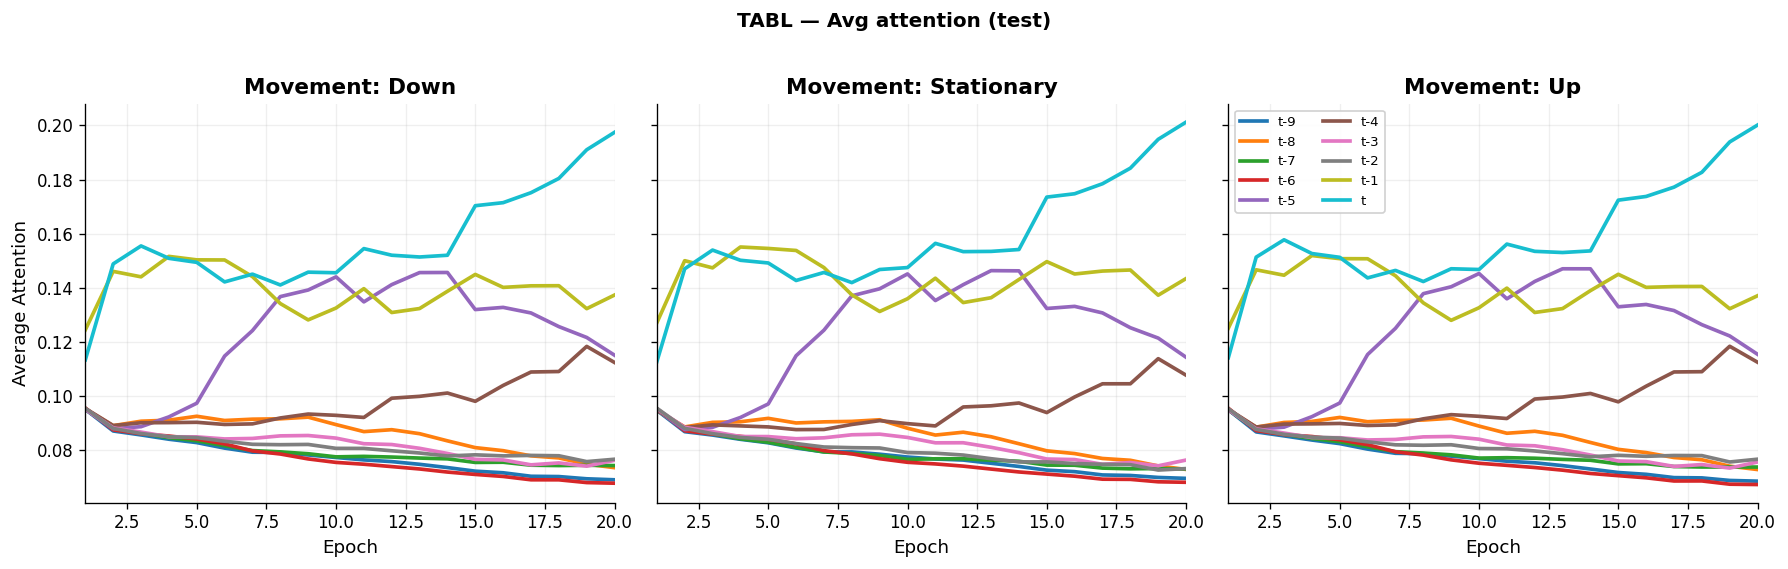

Fold 1 TEST | loss 0.6574 acc 0.7848 macroF1 0.7158

===== Fold 2: Train days 1..2 | Test day 3 =====
Epoch 001 | tr_loss 0.9021 acc 0.6044 | val_loss 0.8105 acc 0.6717 macroF1 0.6108
Epoch 002 | tr_loss 0.7204 acc 0.7179 | val_loss 0.6609 acc 0.7330 macroF1 0.6774
Epoch 003 | tr_loss 0.6348 acc 0.7683 | val_loss 0.6185 acc 0.7568 macroF1 0.7058
Epoch 004 | tr_loss 0.5952 acc 0.7815 | val_loss 0.6075 acc 0.7634 macroF1 0.7086
Epoch 005 | tr_loss 0.5668 acc 0.7875 | val_loss 0.5913 acc 0.7703 macroF1 0.7189
Epoch 006 | tr_loss 0.5442 acc 0.7921 | val_loss 0.5962 acc 0.7633 macroF1 0.7135
Epoch 007 | tr_loss 0.5269 acc 0.7975 | val_loss 0.5862 acc 0.7843 macroF1 0.7323
Epoch 008 | tr_loss 0.5114 acc 0.8017 | val_loss 0.5765 acc 0.7853 macroF1 0.7360
Epoch 009 | tr_loss 0.4981 acc 0.8052 | val_loss 0.5696 acc 0.7721 macroF1 0.7265
Epoch 010 | tr_loss 0.4860 acc 0.8086 | val_loss 0.5771 acc 0.7814 macroF1 0.7326
Epoch 011 | tr_loss 0.4747 acc 0.8114 | val_loss 0.5826 acc 0.7711 macroF1 0.7

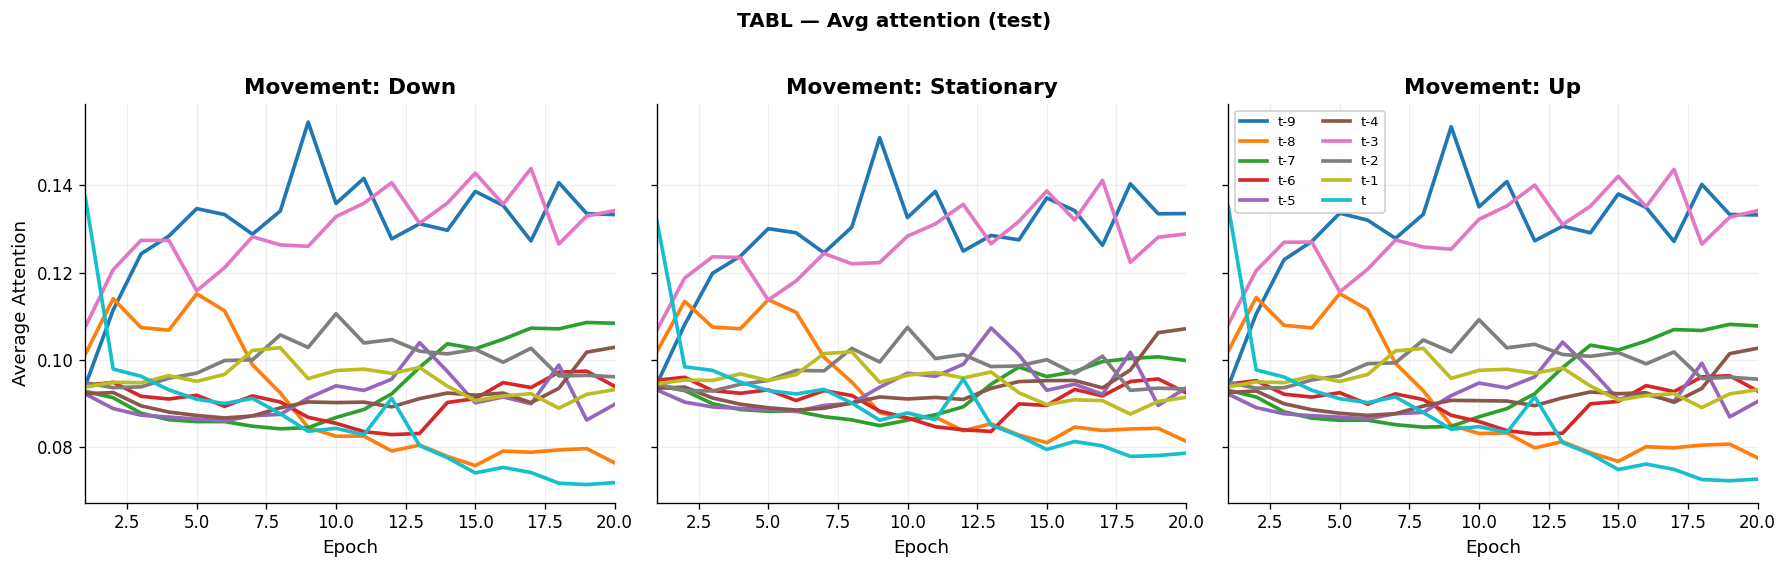

Fold 2 TEST | loss 0.6034 acc 0.7722 macroF1 0.7361

===== Fold 3: Train days 1..3 | Test day 4 =====
Epoch 001 | tr_loss 0.7960 acc 0.6733 | val_loss 0.6097 acc 0.7717 macroF1 0.7039
Epoch 002 | tr_loss 0.6181 acc 0.7743 | val_loss 0.5517 acc 0.8083 macroF1 0.7443
Epoch 003 | tr_loss 0.5665 acc 0.7899 | val_loss 0.5123 acc 0.8196 macroF1 0.7623
Epoch 004 | tr_loss 0.5331 acc 0.7980 | val_loss 0.4939 acc 0.8129 macroF1 0.7597
Epoch 005 | tr_loss 0.5092 acc 0.8032 | val_loss 0.4819 acc 0.8165 macroF1 0.7656
Epoch 006 | tr_loss 0.4904 acc 0.8074 | val_loss 0.4675 acc 0.8196 macroF1 0.7722
Epoch 007 | tr_loss 0.4776 acc 0.8106 | val_loss 0.4801 acc 0.8048 macroF1 0.7557
Epoch 008 | tr_loss 0.4656 acc 0.8135 | val_loss 0.4511 acc 0.8240 macroF1 0.7790
Epoch 009 | tr_loss 0.4572 acc 0.8155 | val_loss 0.4523 acc 0.8176 macroF1 0.7735
Epoch 010 | tr_loss 0.4477 acc 0.8181 | val_loss 0.4480 acc 0.8229 macroF1 0.7771
Epoch 011 | tr_loss 0.4402 acc 0.8196 | val_loss 0.4468 acc 0.8147 macroF1 0.7

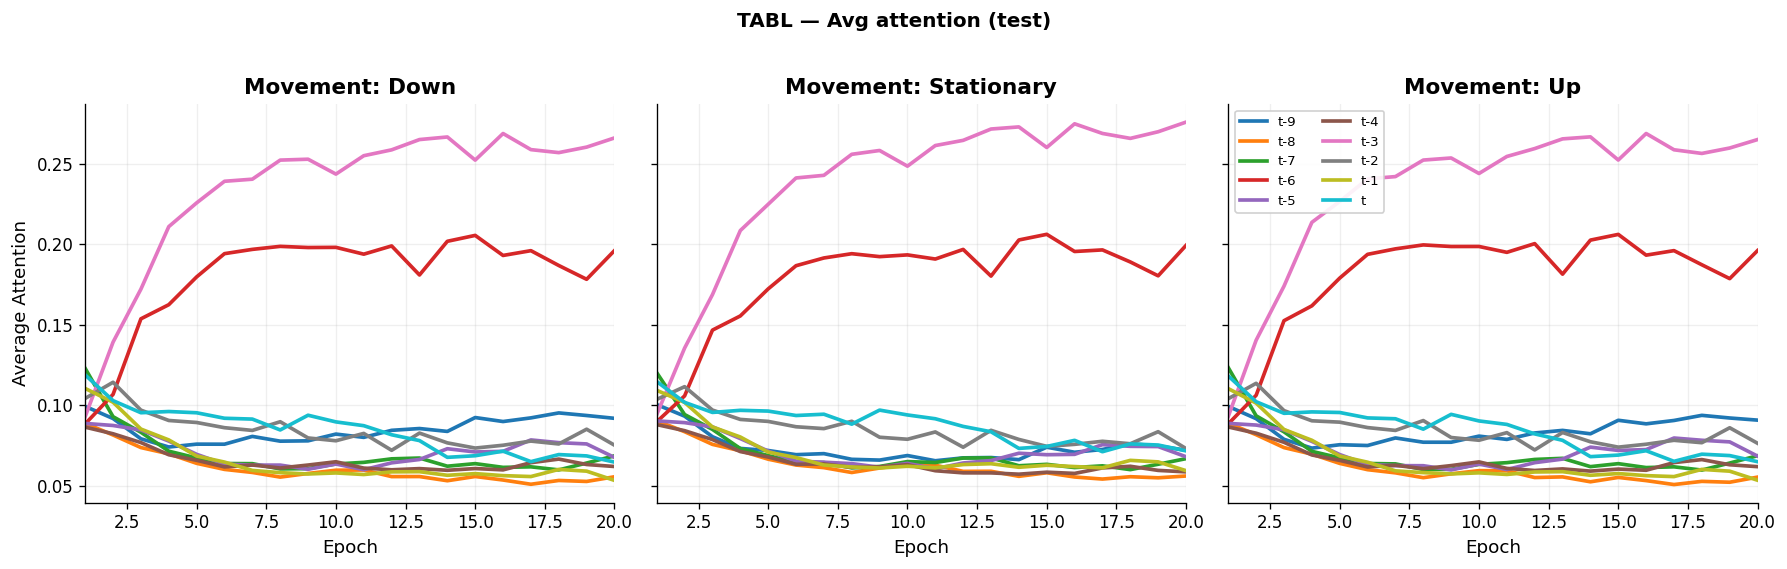

Fold 3 TEST | loss 0.5593 acc 0.7817 macroF1 0.7540

===== Fold 4: Train days 1..4 | Test day 5 =====
Epoch 001 | tr_loss 0.7505 acc 0.7015 | val_loss 0.5943 acc 0.8031 macroF1 0.7279
Epoch 002 | tr_loss 0.5887 acc 0.7834 | val_loss 0.5343 acc 0.7962 macroF1 0.7423
Epoch 003 | tr_loss 0.5389 acc 0.7959 | val_loss 0.4993 acc 0.8036 macroF1 0.7561
Epoch 004 | tr_loss 0.5088 acc 0.8035 | val_loss 0.4742 acc 0.8145 macroF1 0.7697
Epoch 005 | tr_loss 0.4906 acc 0.8075 | val_loss 0.4695 acc 0.8174 macroF1 0.7732
Epoch 006 | tr_loss 0.4751 acc 0.8110 | val_loss 0.4637 acc 0.8147 macroF1 0.7719
Epoch 007 | tr_loss 0.4625 acc 0.8145 | val_loss 0.4521 acc 0.8208 macroF1 0.7787
Epoch 008 | tr_loss 0.4518 acc 0.8164 | val_loss 0.4587 acc 0.8062 macroF1 0.7672
Epoch 009 | tr_loss 0.4450 acc 0.8179 | val_loss 0.4435 acc 0.8210 macroF1 0.7794
Epoch 010 | tr_loss 0.4372 acc 0.8199 | val_loss 0.4392 acc 0.8141 macroF1 0.7760
Epoch 011 | tr_loss 0.4312 acc 0.8211 | val_loss 0.4414 acc 0.8225 macroF1 0.7

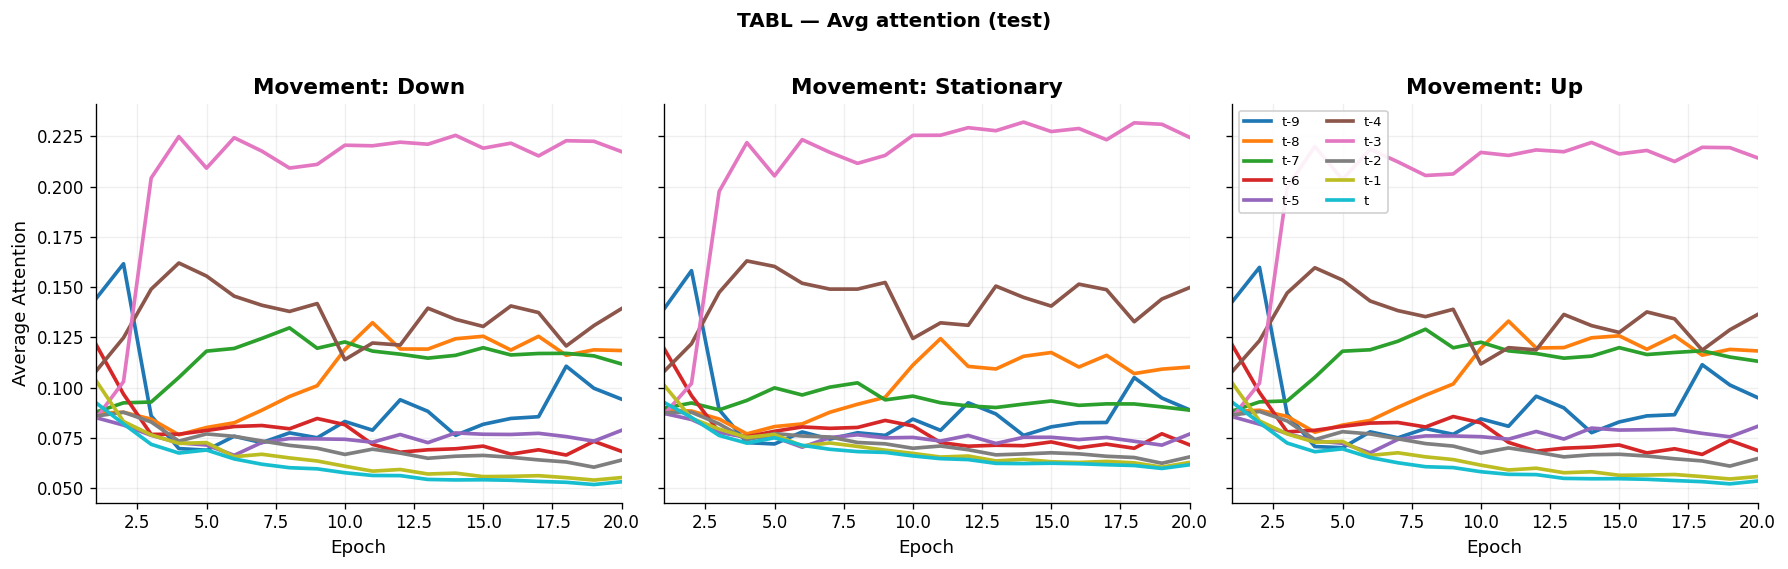

Fold 4 TEST | loss 0.5150 acc 0.8033 macroF1 0.7672

===== Fold 5: Train days 1..5 | Test day 6 =====
Epoch 001 | tr_loss 0.7406 acc 0.7034 | val_loss 0.5794 acc 0.7890 macroF1 0.7287
Epoch 002 | tr_loss 0.5646 acc 0.7893 | val_loss 0.5052 acc 0.7940 macroF1 0.7527
Epoch 003 | tr_loss 0.5110 acc 0.8028 | val_loss 0.4703 acc 0.8088 macroF1 0.7709
Epoch 004 | tr_loss 0.4839 acc 0.8088 | val_loss 0.4460 acc 0.8117 macroF1 0.7758
Epoch 005 | tr_loss 0.4652 acc 0.8124 | val_loss 0.4382 acc 0.8065 macroF1 0.7729
Epoch 006 | tr_loss 0.4512 acc 0.8151 | val_loss 0.4309 acc 0.8124 macroF1 0.7783
Epoch 007 | tr_loss 0.4405 acc 0.8179 | val_loss 0.4239 acc 0.8067 macroF1 0.7759
Epoch 008 | tr_loss 0.4315 acc 0.8192 | val_loss 0.4130 acc 0.8162 macroF1 0.7839
Epoch 009 | tr_loss 0.4242 acc 0.8210 | val_loss 0.4149 acc 0.8168 macroF1 0.7848
Epoch 010 | tr_loss 0.4189 acc 0.8224 | val_loss 0.4072 acc 0.8155 macroF1 0.7849
Epoch 011 | tr_loss 0.4132 acc 0.8241 | val_loss 0.4042 acc 0.8147 macroF1 0.7

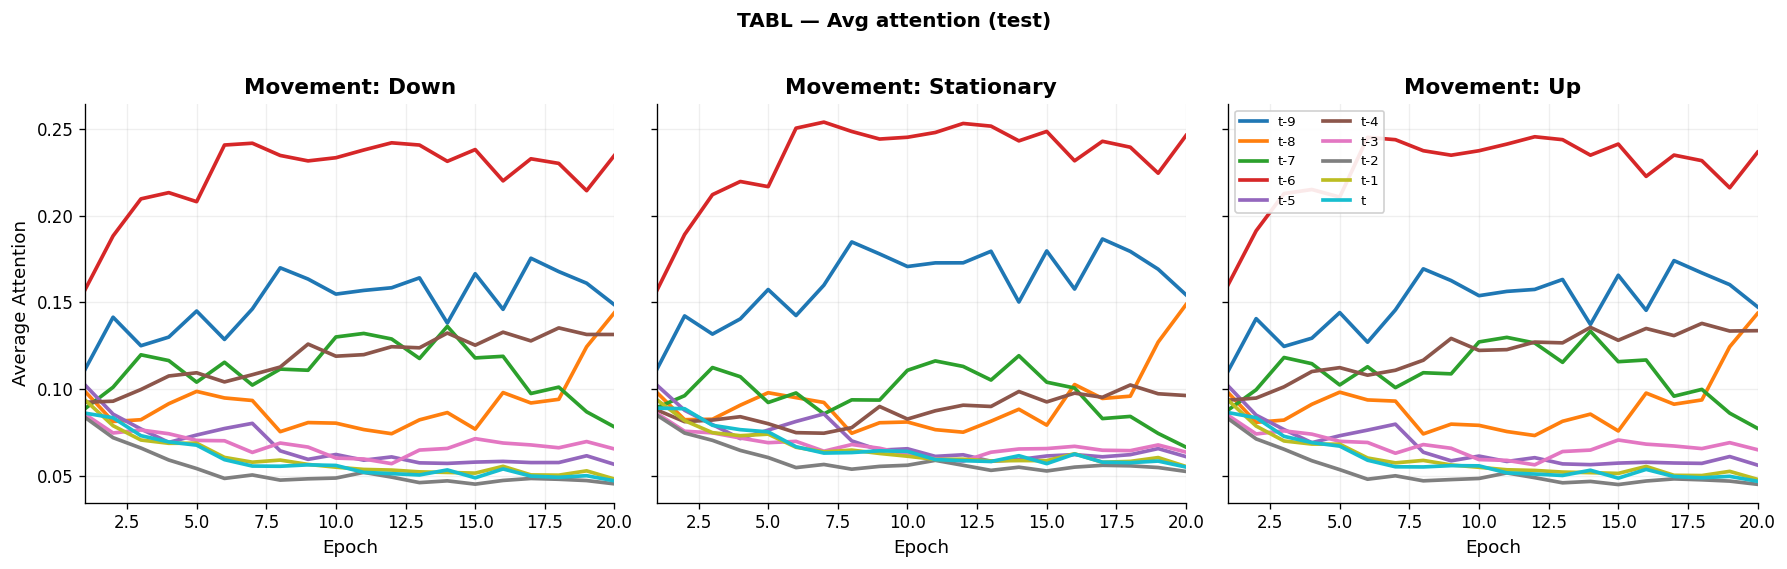

Fold 5 TEST | loss 0.4845 acc 0.8011 macroF1 0.7766

===== Fold 6: Train days 1..6 | Test day 7 =====
Epoch 001 | tr_loss 0.6877 acc 0.7300 | val_loss 0.5417 acc 0.7959 macroF1 0.7420
Epoch 002 | tr_loss 0.5361 acc 0.7956 | val_loss 0.4705 acc 0.8104 macroF1 0.7689
Epoch 003 | tr_loss 0.4895 acc 0.8066 | val_loss 0.4392 acc 0.8157 macroF1 0.7786
Epoch 004 | tr_loss 0.4666 acc 0.8117 | val_loss 0.4253 acc 0.8150 macroF1 0.7799
Epoch 005 | tr_loss 0.4508 acc 0.8150 | val_loss 0.4146 acc 0.8192 macroF1 0.7836
Epoch 006 | tr_loss 0.4400 acc 0.8173 | val_loss 0.4042 acc 0.8274 macroF1 0.7923
Epoch 007 | tr_loss 0.4299 acc 0.8200 | val_loss 0.3981 acc 0.8186 macroF1 0.7854
Epoch 008 | tr_loss 0.4232 acc 0.8219 | val_loss 0.3930 acc 0.8273 macroF1 0.7940
Epoch 009 | tr_loss 0.4165 acc 0.8228 | val_loss 0.3927 acc 0.8228 macroF1 0.7913
Epoch 010 | tr_loss 0.4115 acc 0.8247 | val_loss 0.3875 acc 0.8242 macroF1 0.7926
Epoch 011 | tr_loss 0.4073 acc 0.8257 | val_loss 0.3827 acc 0.8301 macroF1 0.7

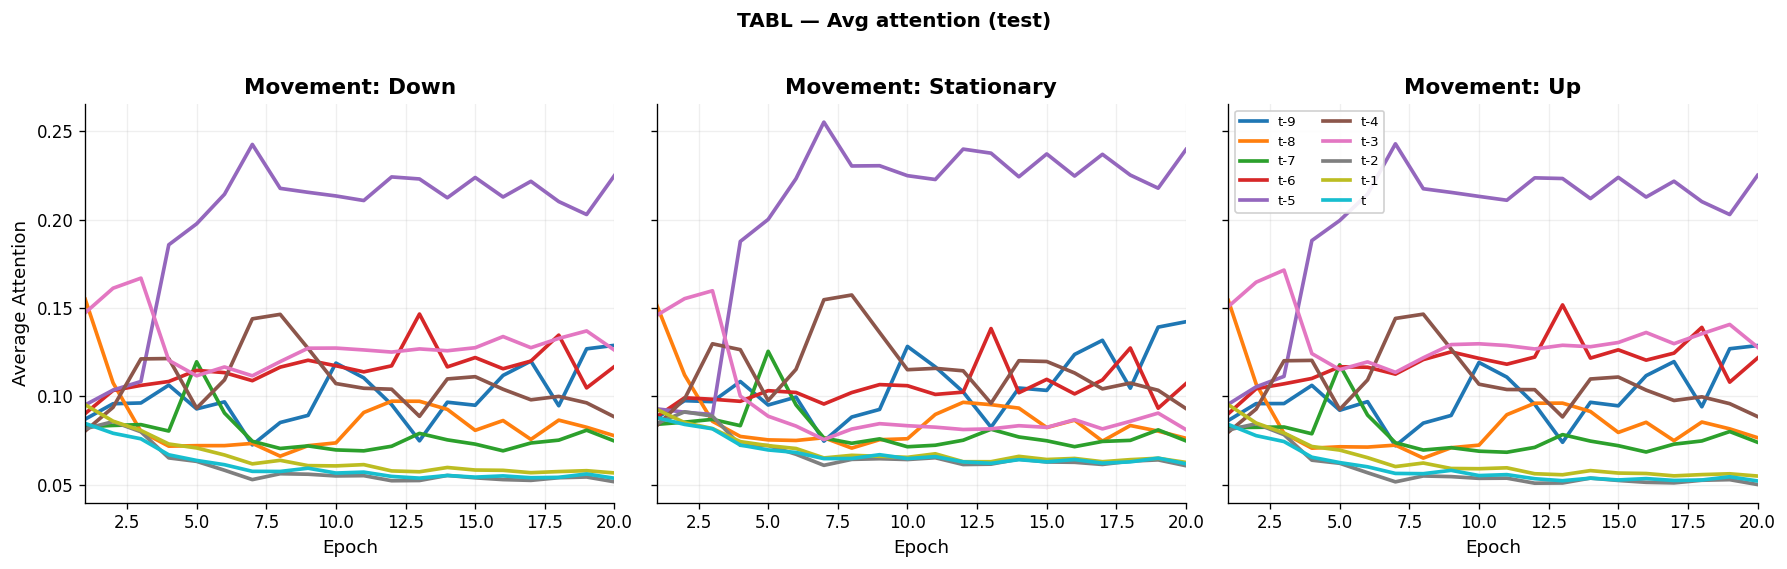

Fold 6 TEST | loss 0.3588 acc 0.8675 macroF1 0.7973

===== Fold 7: Train days 1..7 | Test day 8 =====
Epoch 001 | tr_loss 0.6327 acc 0.7562 | val_loss 0.4890 acc 0.8106 macroF1 0.7661
Epoch 002 | tr_loss 0.5079 acc 0.8025 | val_loss 0.4488 acc 0.8165 macroF1 0.7769
Epoch 003 | tr_loss 0.4780 acc 0.8088 | val_loss 0.4355 acc 0.8111 macroF1 0.7745
Epoch 004 | tr_loss 0.4595 acc 0.8122 | val_loss 0.4169 acc 0.8198 macroF1 0.7844
Epoch 005 | tr_loss 0.4473 acc 0.8144 | val_loss 0.4050 acc 0.8207 macroF1 0.7858
Epoch 006 | tr_loss 0.4374 acc 0.8162 | val_loss 0.4031 acc 0.8177 macroF1 0.7840
Epoch 007 | tr_loss 0.4303 acc 0.8173 | val_loss 0.3966 acc 0.8217 macroF1 0.7879
Epoch 008 | tr_loss 0.4233 acc 0.8184 | val_loss 0.3927 acc 0.8212 macroF1 0.7878
Epoch 009 | tr_loss 0.4172 acc 0.8194 | val_loss 0.3880 acc 0.8224 macroF1 0.7896
Epoch 010 | tr_loss 0.4121 acc 0.8204 | val_loss 0.3856 acc 0.8229 macroF1 0.7904
Epoch 011 | tr_loss 0.4082 acc 0.8212 | val_loss 0.3813 acc 0.8254 macroF1 0.7

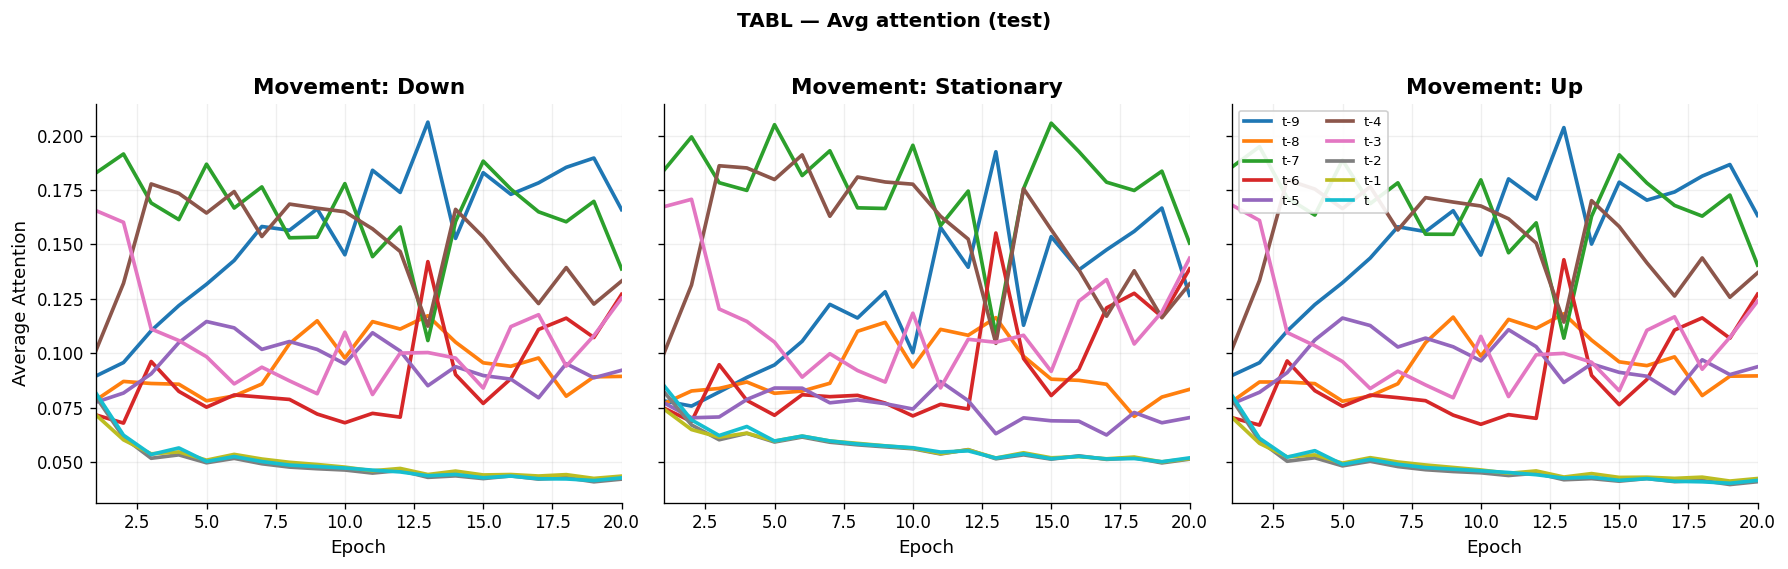

Fold 7 TEST | loss 0.3911 acc 0.8492 macroF1 0.7895

===== Fold 8: Train days 1..8 | Test day 9 =====
Epoch 001 | tr_loss 0.6159 acc 0.7599 | val_loss 0.4556 acc 0.8233 macroF1 0.7701
Epoch 002 | tr_loss 0.4945 acc 0.8047 | val_loss 0.4187 acc 0.8307 macroF1 0.7809
Epoch 003 | tr_loss 0.4663 acc 0.8092 | val_loss 0.3963 acc 0.8304 macroF1 0.7847
Epoch 004 | tr_loss 0.4492 acc 0.8129 | val_loss 0.3846 acc 0.8342 macroF1 0.7895
Epoch 005 | tr_loss 0.4385 acc 0.8151 | val_loss 0.3874 acc 0.8285 macroF1 0.7848
Epoch 006 | tr_loss 0.4300 acc 0.8169 | val_loss 0.3835 acc 0.8285 macroF1 0.7849
Epoch 007 | tr_loss 0.4240 acc 0.8175 | val_loss 0.3757 acc 0.8288 macroF1 0.7867
Epoch 008 | tr_loss 0.4186 acc 0.8187 | val_loss 0.3610 acc 0.8377 macroF1 0.7953
Epoch 009 | tr_loss 0.4139 acc 0.8194 | val_loss 0.3609 acc 0.8380 macroF1 0.7955
Epoch 010 | tr_loss 0.4104 acc 0.8204 | val_loss 0.3596 acc 0.8366 macroF1 0.7949
Epoch 011 | tr_loss 0.4071 acc 0.8211 | val_loss 0.3569 acc 0.8358 macroF1 0.7

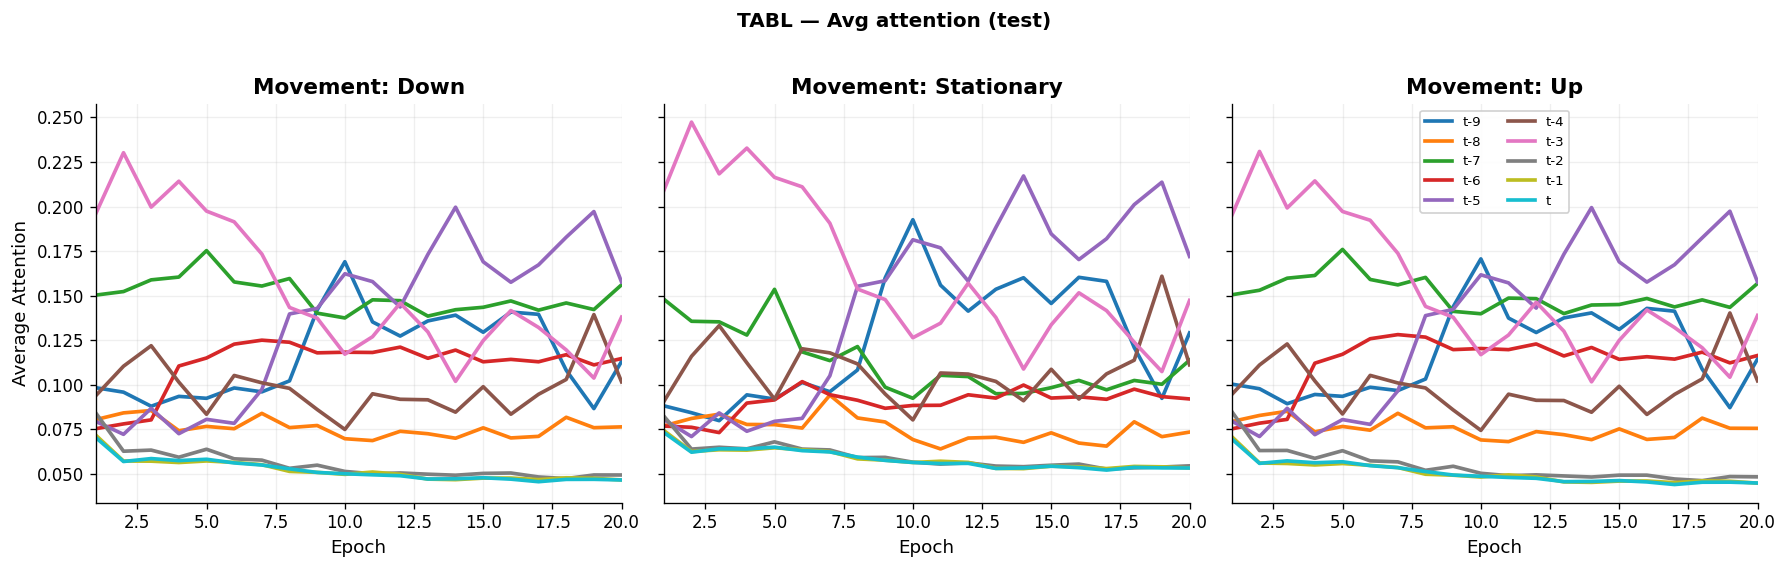

Fold 8 TEST | loss 0.4047 acc 0.8367 macroF1 0.7908

===== WALK-FORWARD SUMMARY: TABL =====
Test Accuracy  | mean=0.8121 std=0.0326
Test Macro F1  | mean=0.7659 std=0.0270


In [168]:
tabl_results = run_walk_forward_cv(
    model_builder=lambda: TABLClassifier(
        num_classes=3,
        in_dim=144,
        in_time=10,
        hidden_dim=64,
        hidden_time=5,
        classifier_dim=64,
    ),
    model_name="TABL",
    val_ratio=0.1,
    track_attention=True,
    attention_every=1,
    attention_on="test",
    attention_collector=collect_avg_tabl_attention_per_class,
    plot_attention=True,
    plot_attention_title="TABL — Avg attention (test)",
)


MODEL (Walk-Forward CV): TLOB


===== Fold 1: Train days 1..1 | Test day 2 =====
Epoch 001 | tr_loss 0.5991 acc 0.7498 | val_loss 0.5630 acc 0.7927 macroF1 0.7643
Epoch 002 | tr_loss 0.4560 acc 0.8176 | val_loss 0.4954 acc 0.7920 macroF1 0.7694
Epoch 003 | tr_loss 0.4142 acc 0.8260 | val_loss 0.5254 acc 0.7930 macroF1 0.7663
Epoch 004 | tr_loss 0.3840 acc 0.8292 | val_loss 0.5303 acc 0.7937 macroF1 0.7685
Epoch 005 | tr_loss 0.3554 acc 0.8373 | val_loss 0.5216 acc 0.7932 macroF1 0.7685
Epoch 006 | tr_loss 0.3263 acc 0.8452 | val_loss 0.5410 acc 0.7798 macroF1 0.7568
Epoch 007 | tr_loss 0.3063 acc 0.8485 | val_loss 0.5398 acc 0.7831 macroF1 0.7605
Epoch 008 | tr_loss 0.2829 acc 0.8588 | val_loss 0.6074 acc 0.7770 macroF1 0.7533
Epoch 009 | tr_loss 0.2603 acc 0.8670 | val_loss 0.6288 acc 0.7775 macroF1 0.7513
Epoch 010 | tr_loss 0.2455 acc 0.8738 | val_loss 0.6431 acc 0.7732 macroF1 0.7497
Epoch 011 | tr_loss 0.2305 acc 0.8790 | val_loss 0.7076 acc 0.7783 macroF1 0.7538
Epoch 012 | tr_l

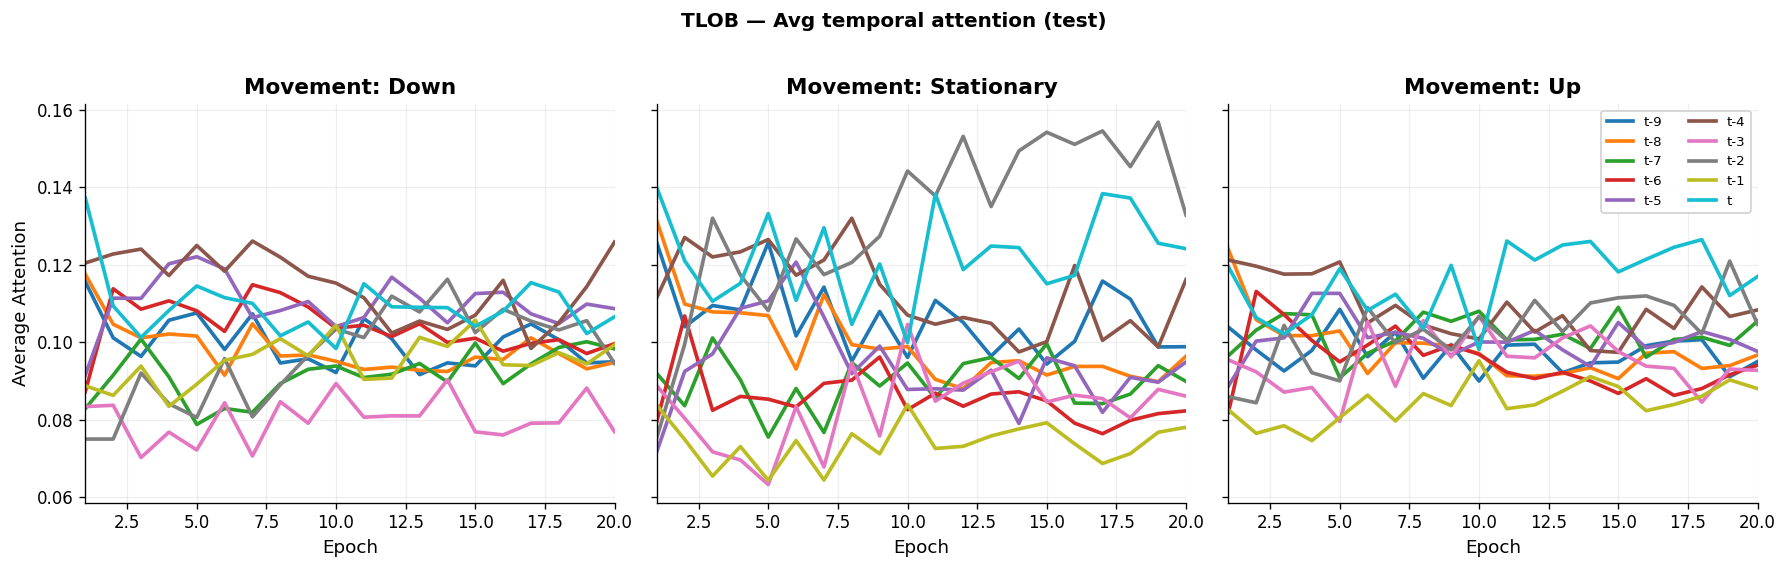

Fold 1 TEST | loss 0.4120 acc 0.8266 macroF1 0.7930

===== Fold 2: Train days 1..2 | Test day 3 =====
Epoch 001 | tr_loss 0.5222 acc 0.7837 | val_loss 0.4157 acc 0.8105 macroF1 0.7850
Epoch 002 | tr_loss 0.4103 acc 0.8190 | val_loss 0.3912 acc 0.8171 macroF1 0.7908
Epoch 003 | tr_loss 0.3773 acc 0.8262 | val_loss 0.4051 acc 0.8090 macroF1 0.7828
Epoch 004 | tr_loss 0.3501 acc 0.8326 | val_loss 0.4269 acc 0.7980 macroF1 0.7727
Epoch 005 | tr_loss 0.3239 acc 0.8401 | val_loss 0.4413 acc 0.8078 macroF1 0.7814
Epoch 006 | tr_loss 0.3009 acc 0.8481 | val_loss 0.4366 acc 0.8154 macroF1 0.7877
Epoch 007 | tr_loss 0.2789 acc 0.8563 | val_loss 0.4732 acc 0.8082 macroF1 0.7808
Epoch 008 | tr_loss 0.2569 acc 0.8657 | val_loss 0.5008 acc 0.8195 macroF1 0.7889
Epoch 009 | tr_loss 0.2397 acc 0.8734 | val_loss 0.5278 acc 0.8118 macroF1 0.7803
Epoch 010 | tr_loss 0.2238 acc 0.8812 | val_loss 0.5590 acc 0.8182 macroF1 0.7865
Epoch 011 | tr_loss 0.2082 acc 0.8884 | val_loss 0.6156 acc 0.8165 macroF1 0.7

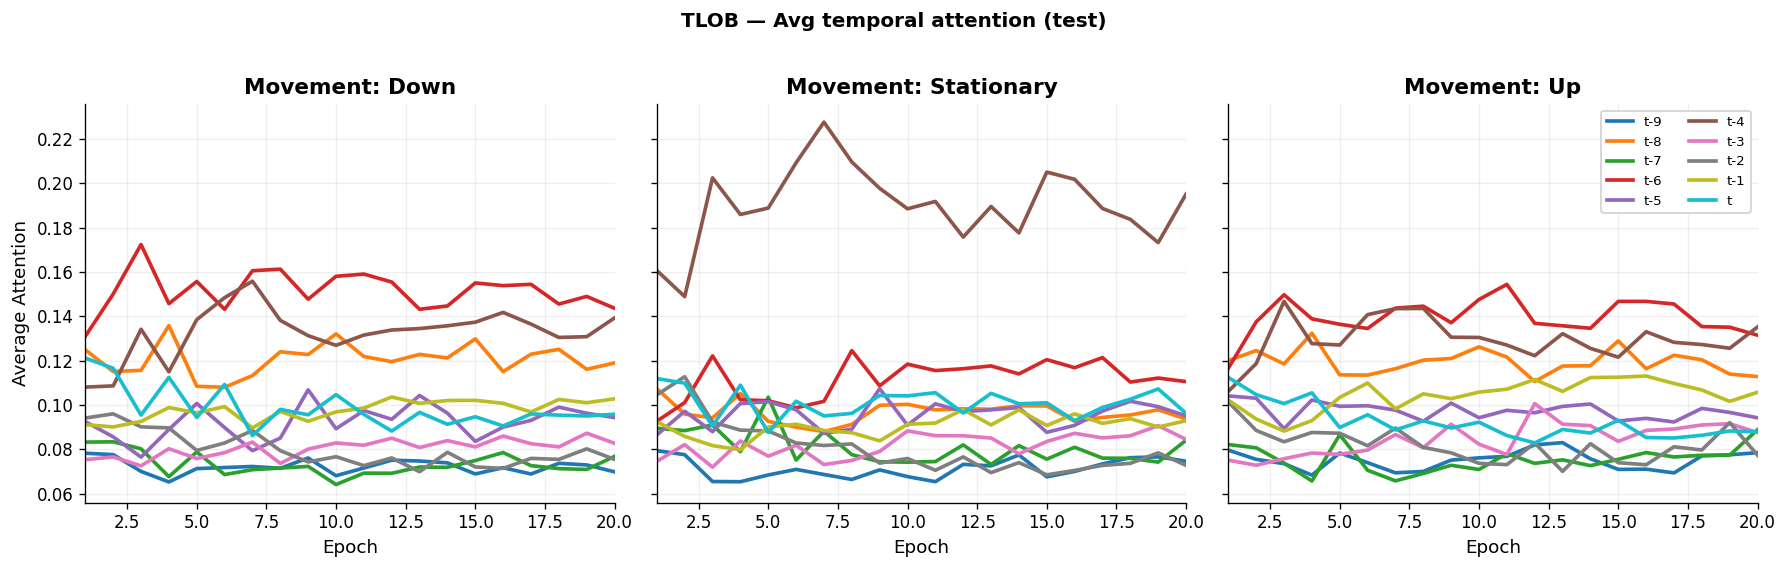

Fold 2 TEST | loss 0.8017 acc 0.8190 macroF1 0.7884

===== Fold 3: Train days 1..3 | Test day 4 =====
Epoch 001 | tr_loss 0.4653 acc 0.8026 | val_loss 0.3705 acc 0.8248 macroF1 0.7917
Epoch 002 | tr_loss 0.3850 acc 0.8213 | val_loss 0.3578 acc 0.8309 macroF1 0.7967
Epoch 003 | tr_loss 0.3521 acc 0.8276 | val_loss 0.3462 acc 0.8253 macroF1 0.7942
Epoch 004 | tr_loss 0.3242 acc 0.8345 | val_loss 0.3452 acc 0.8331 macroF1 0.8028
Epoch 005 | tr_loss 0.2971 acc 0.8425 | val_loss 0.3477 acc 0.8453 macroF1 0.8140
Epoch 006 | tr_loss 0.2752 acc 0.8514 | val_loss 0.3465 acc 0.8454 macroF1 0.8151
Epoch 007 | tr_loss 0.2544 acc 0.8601 | val_loss 0.3526 acc 0.8488 macroF1 0.8200
Epoch 008 | tr_loss 0.2356 acc 0.8686 | val_loss 0.3391 acc 0.8527 macroF1 0.8249
Epoch 009 | tr_loss 0.2190 acc 0.8780 | val_loss 0.3496 acc 0.8608 macroF1 0.8332
Epoch 010 | tr_loss 0.2035 acc 0.8864 | val_loss 0.3516 acc 0.8701 macroF1 0.8430
Epoch 011 | tr_loss 0.1906 acc 0.8940 | val_loss 0.3552 acc 0.8689 macroF1 0.8

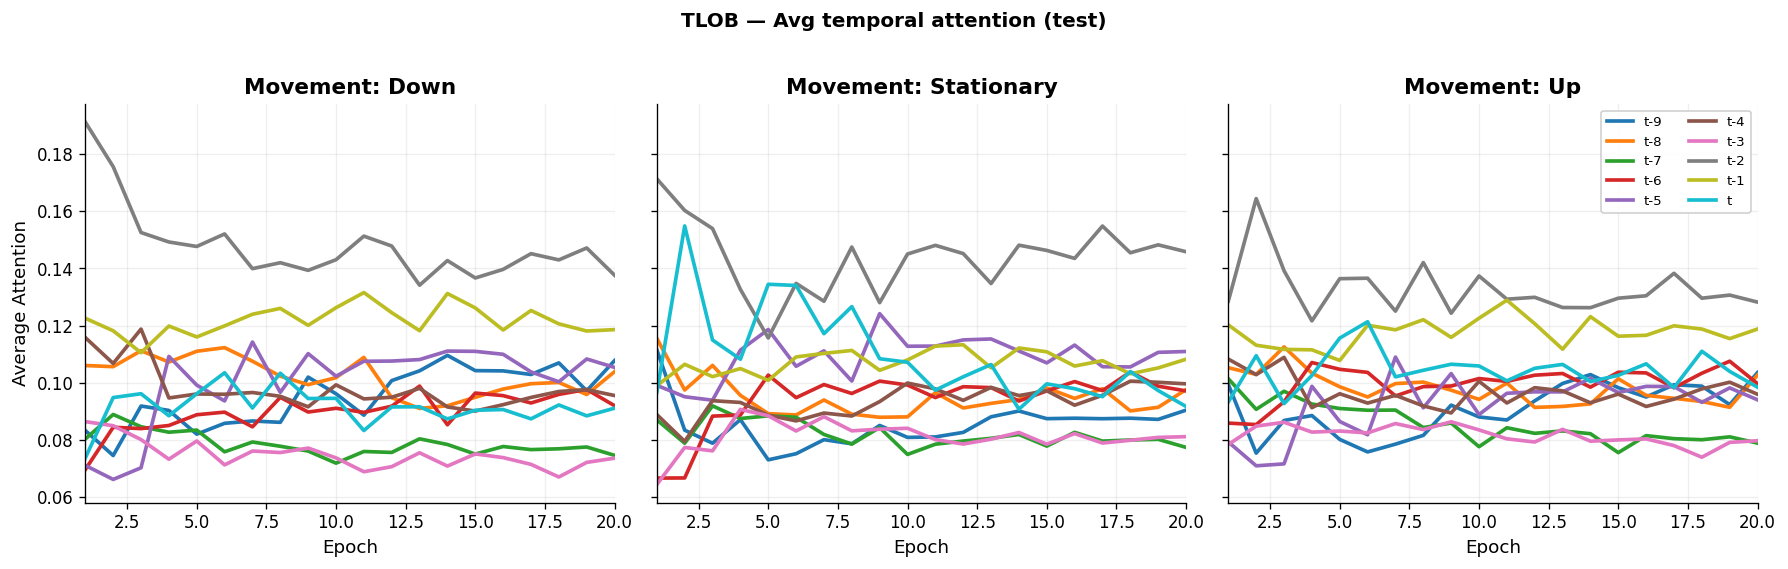

Fold 3 TEST | loss 0.7978 acc 0.8122 macroF1 0.7877

===== Fold 4: Train days 1..4 | Test day 5 =====
Epoch 001 | tr_loss 0.4392 acc 0.8083 | val_loss 0.3639 acc 0.8256 macroF1 0.7935
Epoch 002 | tr_loss 0.3640 acc 0.8253 | val_loss 0.3447 acc 0.8245 macroF1 0.7967
Epoch 003 | tr_loss 0.3303 acc 0.8332 | val_loss 0.3327 acc 0.8322 macroF1 0.8058
Epoch 004 | tr_loss 0.2979 acc 0.8445 | val_loss 0.3278 acc 0.8446 macroF1 0.8176
Epoch 005 | tr_loss 0.2688 acc 0.8562 | val_loss 0.3146 acc 0.8412 macroF1 0.8165
Epoch 006 | tr_loss 0.2423 acc 0.8676 | val_loss 0.3014 acc 0.8638 macroF1 0.8393
Epoch 007 | tr_loss 0.2206 acc 0.8794 | val_loss 0.2964 acc 0.8743 macroF1 0.8506
Epoch 008 | tr_loss 0.2014 acc 0.8895 | val_loss 0.3016 acc 0.8847 macroF1 0.8611
Epoch 009 | tr_loss 0.1859 acc 0.9000 | val_loss 0.2897 acc 0.8887 macroF1 0.8659
Epoch 010 | tr_loss 0.1699 acc 0.9095 | val_loss 0.2908 acc 0.8897 macroF1 0.8684
Epoch 011 | tr_loss 0.1568 acc 0.9180 | val_loss 0.2877 acc 0.8990 macroF1 0.8

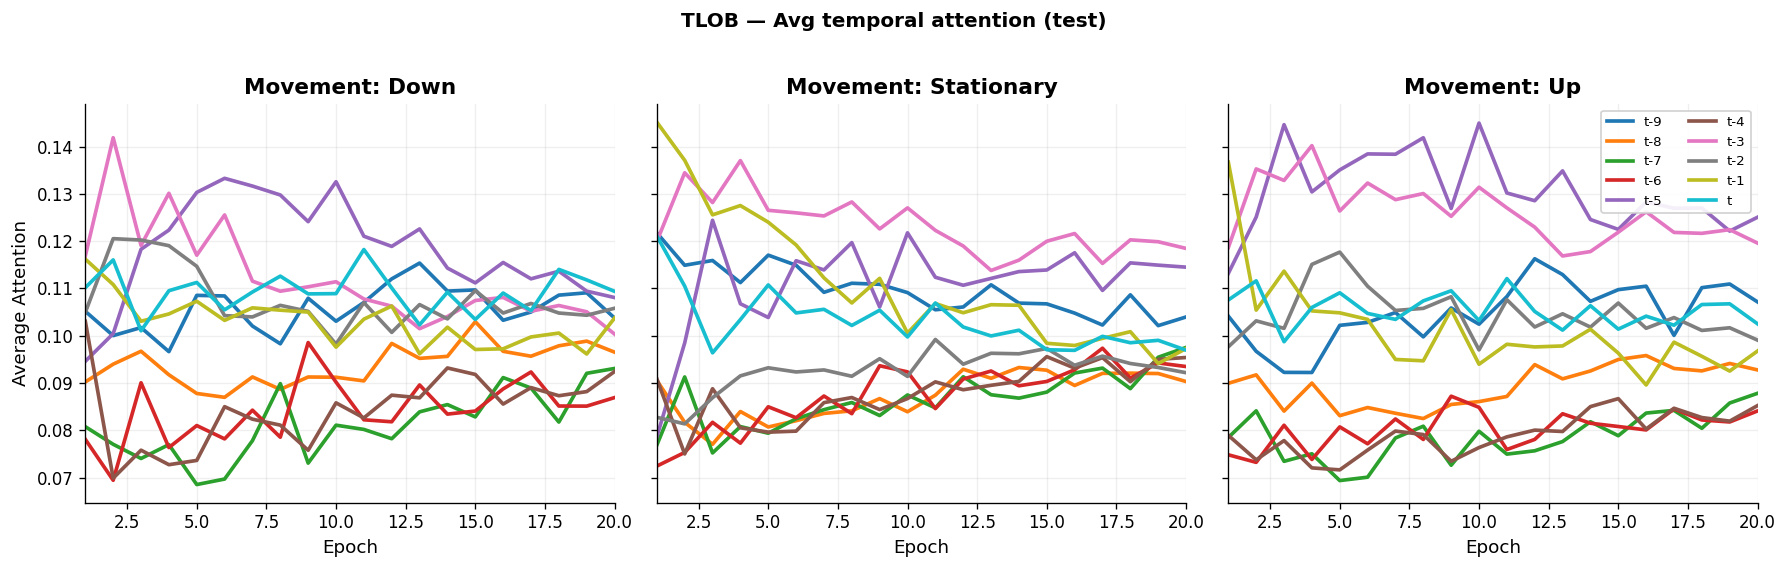

Fold 4 TEST | loss 0.8828 acc 0.8331 macroF1 0.7981

===== Fold 5: Train days 1..5 | Test day 6 =====
Epoch 001 | tr_loss 0.4194 acc 0.8129 | val_loss 0.3551 acc 0.8161 macroF1 0.7916
Epoch 002 | tr_loss 0.3597 acc 0.8240 | val_loss 0.3432 acc 0.8362 macroF1 0.8105
Epoch 003 | tr_loss 0.3258 acc 0.8316 | val_loss 0.3253 acc 0.8270 macroF1 0.8060
Epoch 004 | tr_loss 0.2964 acc 0.8424 | val_loss 0.3106 acc 0.8407 macroF1 0.8204
Epoch 005 | tr_loss 0.2695 acc 0.8540 | val_loss 0.2954 acc 0.8472 macroF1 0.8278
Epoch 006 | tr_loss 0.2465 acc 0.8644 | val_loss 0.2816 acc 0.8565 macroF1 0.8381
Epoch 007 | tr_loss 0.2271 acc 0.8757 | val_loss 0.2753 acc 0.8606 macroF1 0.8432
Epoch 008 | tr_loss 0.2091 acc 0.8865 | val_loss 0.2655 acc 0.8739 macroF1 0.8566
Epoch 009 | tr_loss 0.1942 acc 0.8958 | val_loss 0.2582 acc 0.8901 macroF1 0.8722
Epoch 010 | tr_loss 0.1801 acc 0.9047 | val_loss 0.2516 acc 0.8947 macroF1 0.8782
Epoch 011 | tr_loss 0.1687 acc 0.9124 | val_loss 0.2530 acc 0.8911 macroF1 0.8

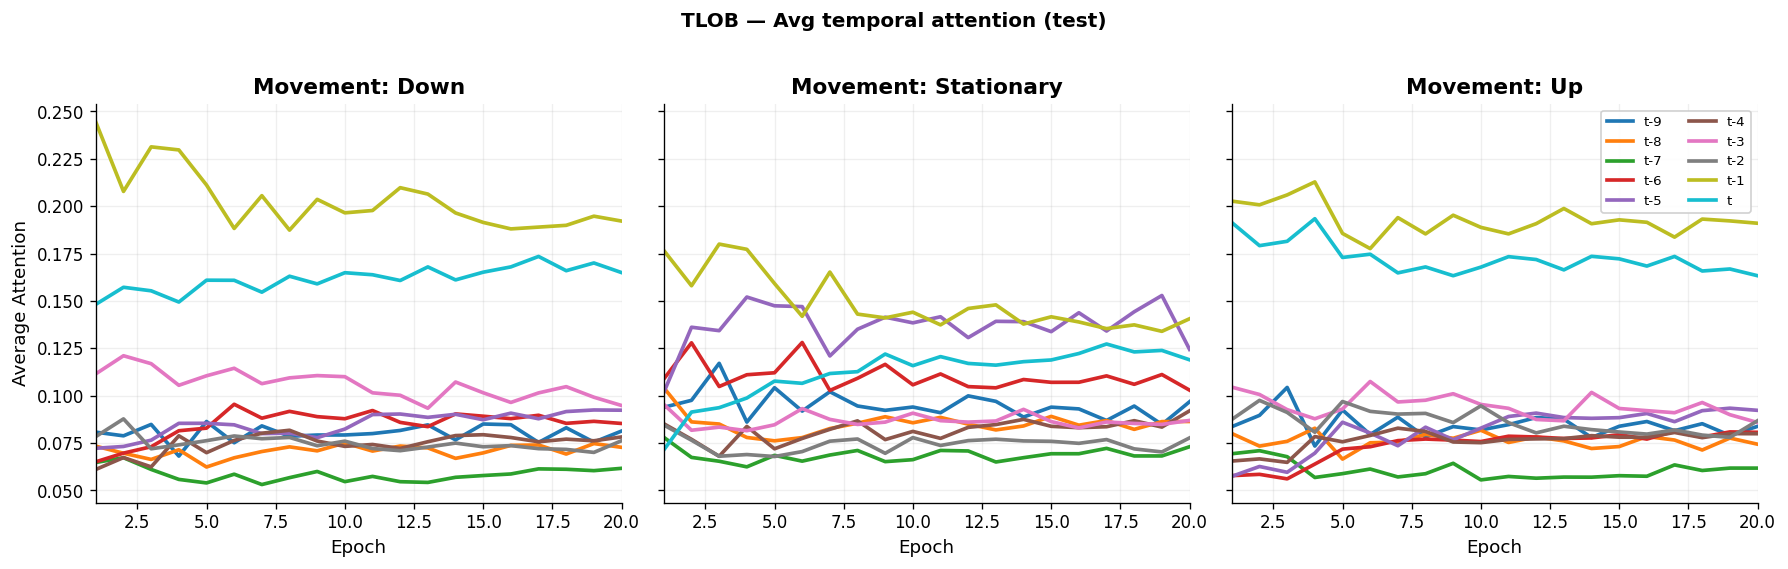

Fold 5 TEST | loss 0.8443 acc 0.8240 macroF1 0.7955

===== Fold 6: Train days 1..6 | Test day 7 =====
Epoch 001 | tr_loss 0.4087 acc 0.8125 | val_loss 0.3461 acc 0.8228 macroF1 0.7964
Epoch 002 | tr_loss 0.3518 acc 0.8238 | val_loss 0.3304 acc 0.8302 macroF1 0.8042
Epoch 003 | tr_loss 0.3211 acc 0.8328 | val_loss 0.3140 acc 0.8417 macroF1 0.8171
Epoch 004 | tr_loss 0.2924 acc 0.8423 | val_loss 0.2998 acc 0.8530 macroF1 0.8292
Epoch 005 | tr_loss 0.2665 acc 0.8534 | val_loss 0.2867 acc 0.8591 macroF1 0.8369
Epoch 006 | tr_loss 0.2436 acc 0.8647 | val_loss 0.2757 acc 0.8611 macroF1 0.8414
Epoch 007 | tr_loss 0.2234 acc 0.8757 | val_loss 0.2784 acc 0.8737 macroF1 0.8539
Epoch 008 | tr_loss 0.2062 acc 0.8863 | val_loss 0.2580 acc 0.8886 macroF1 0.8692
Epoch 009 | tr_loss 0.1917 acc 0.8958 | val_loss 0.2605 acc 0.8920 macroF1 0.8733
Epoch 010 | tr_loss 0.1788 acc 0.9047 | val_loss 0.2617 acc 0.9002 macroF1 0.8817
Epoch 011 | tr_loss 0.1673 acc 0.9126 | val_loss 0.2581 acc 0.9083 macroF1 0.8

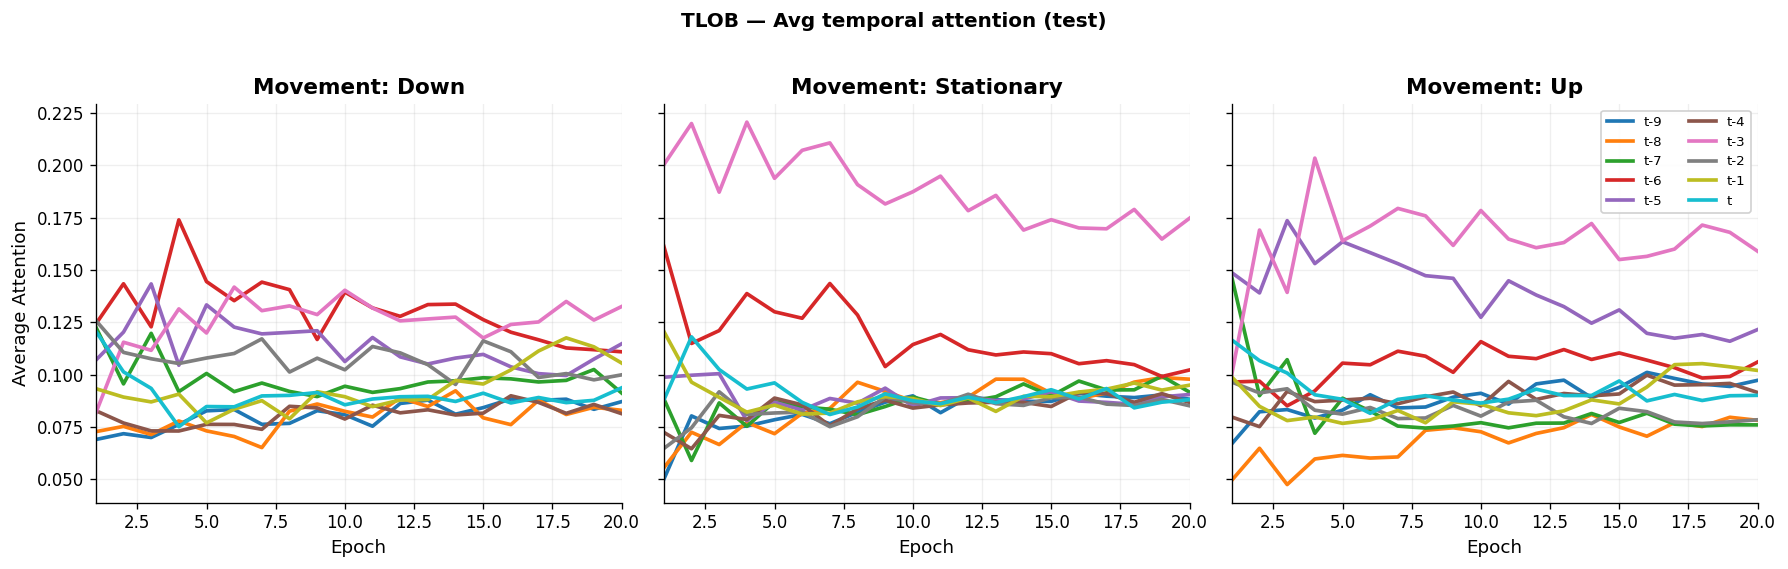

Fold 6 TEST | loss 0.6192 acc 0.8825 macroF1 0.8117

===== Fold 7: Train days 1..7 | Test day 8 =====
Epoch 001 | tr_loss 0.4019 acc 0.8134 | val_loss 0.3414 acc 0.8193 macroF1 0.7924
Epoch 002 | tr_loss 0.3464 acc 0.8243 | val_loss 0.3210 acc 0.8330 macroF1 0.8074
Epoch 003 | tr_loss 0.3120 acc 0.8353 | val_loss 0.3089 acc 0.8314 macroF1 0.8082
Epoch 004 | tr_loss 0.2804 acc 0.8479 | val_loss 0.2866 acc 0.8506 macroF1 0.8276
Epoch 005 | tr_loss 0.2544 acc 0.8609 | val_loss 0.2678 acc 0.8658 macroF1 0.8444
Epoch 006 | tr_loss 0.2320 acc 0.8732 | val_loss 0.2632 acc 0.8681 macroF1 0.8482
Epoch 007 | tr_loss 0.2127 acc 0.8842 | val_loss 0.2537 acc 0.8909 macroF1 0.8704
Epoch 008 | tr_loss 0.1970 acc 0.8940 | val_loss 0.2424 acc 0.8831 macroF1 0.8645
Epoch 009 | tr_loss 0.1830 acc 0.9031 | val_loss 0.2407 acc 0.8980 macroF1 0.8798
Epoch 010 | tr_loss 0.1704 acc 0.9113 | val_loss 0.2282 acc 0.9013 macroF1 0.8836
Epoch 011 | tr_loss 0.1596 acc 0.9181 | val_loss 0.2312 acc 0.9107 macroF1 0.8

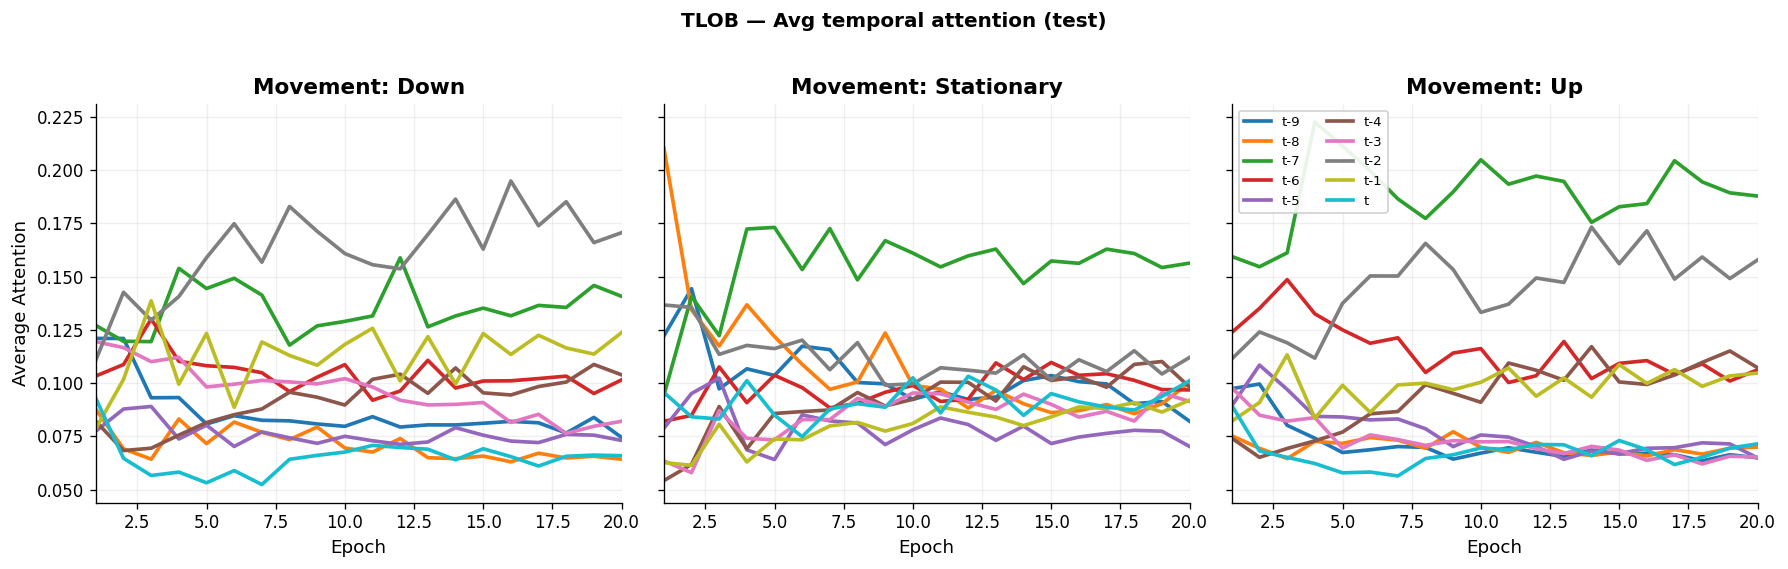

Fold 7 TEST | loss 0.6539 acc 0.8656 macroF1 0.8040

===== Fold 8: Train days 1..8 | Test day 9 =====
Epoch 001 | tr_loss 0.3930 acc 0.8150 | val_loss 0.3207 acc 0.8340 macroF1 0.7976
Epoch 002 | tr_loss 0.3382 acc 0.8260 | val_loss 0.2958 acc 0.8477 macroF1 0.8131
Epoch 003 | tr_loss 0.3024 acc 0.8379 | val_loss 0.2800 acc 0.8506 macroF1 0.8190
Epoch 004 | tr_loss 0.2697 acc 0.8512 | val_loss 0.2632 acc 0.8659 macroF1 0.8355
Epoch 005 | tr_loss 0.2428 acc 0.8647 | val_loss 0.2465 acc 0.8730 macroF1 0.8453
Epoch 006 | tr_loss 0.2214 acc 0.8777 | val_loss 0.2397 acc 0.8892 macroF1 0.8620
Epoch 007 | tr_loss 0.2027 acc 0.8894 | val_loss 0.2379 acc 0.8959 macroF1 0.8704
Epoch 008 | tr_loss 0.1860 acc 0.9008 | val_loss 0.2269 acc 0.9020 macroF1 0.8775
Epoch 009 | tr_loss 0.1722 acc 0.9096 | val_loss 0.2188 acc 0.9106 macroF1 0.8872
Epoch 010 | tr_loss 0.1608 acc 0.9179 | val_loss 0.2187 acc 0.9175 macroF1 0.8950
Epoch 011 | tr_loss 0.1495 acc 0.9252 | val_loss 0.2175 acc 0.9204 macroF1 0.8

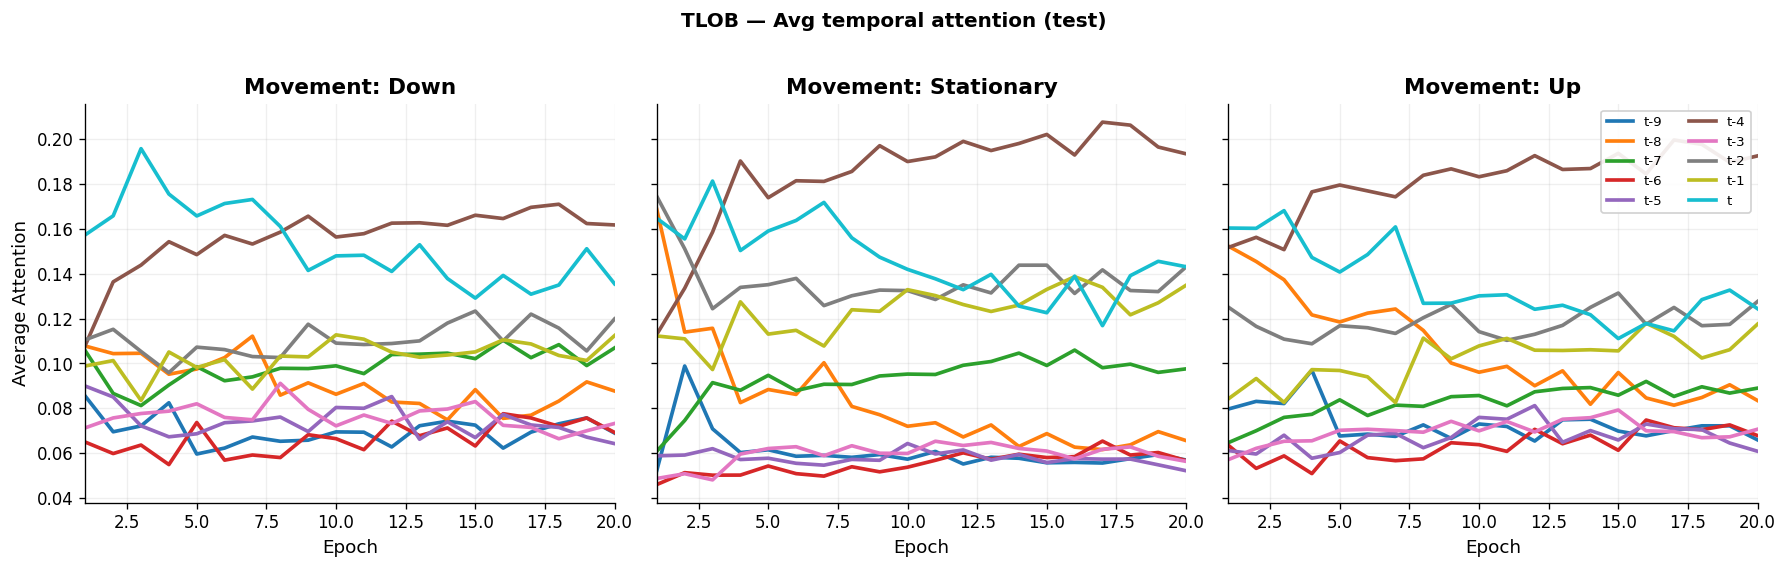

Fold 8 TEST | loss 0.6746 acc 0.8513 macroF1 0.8021

===== WALK-FORWARD SUMMARY: TLOB =====
Test Accuracy  | mean=0.8393 std=0.0231
Test Macro F1  | mean=0.7976 std=0.0076


In [169]:
tlob_results = run_walk_forward_cv(
    model_builder=lambda: TLOBClassifier(
        num_classes=3,
        input_dim=144,
        time_steps=10,
        d_model=144,
        n_layers=2,
        n_heads_time=4,
        d_feat_attn=64,
        n_heads_feat=4,
        dropout=0.1,
        use_bin=True,
        use_pos_enc=True,
        cls_pool="last",
    ),

    model_name="TLOB",
    epochs=20,
    lr=1e-3,
    val_ratio=0.1,
    track_attention=True,
    attention_on='test',
    attention_every=1,
    attention_collector=collect_avg_time_attention_per_class,
    plot_attention=True,
    plot_attention_title="TLOB — Avg temporal attention (test)"
)

In [189]:
df_mlp, sum_mlp = summarize_cv(mlp_results, "MLP")
df_cnn, sum_cnn = summarize_cv(cnn_results, "CNN")
df_lstm, sum_lstm = summarize_cv(lstm_results, "LSTM")
df_tcn, sum_tcn = summarize_cv(tcn_results, "TCN")
df_tabl, sum_tabl = summarize_cv(tabl_results, "TABL")
df_tlob, sum_tlob = summarize_cv(tlob_results, "TLOB")


In [190]:
summary_df = pd.DataFrame([sum_mlp, sum_cnn, sum_lstm, sum_tcn, sum_tlob, sum_tabl]).sort_values("f1_mean", ascending=False)
summary_df


,model,acc_mean,acc_std,f1_mean,f1_std
4,TLOB,0.839284,0.023135,0.797581,0.007649
5,TABL,0.812072,0.032609,0.765896,0.026979
3,TCN,0.796807,0.052138,0.747439,0.050092
1,CNN,0.785589,0.032106,0.730338,0.025818
0,MLP,0.777988,0.064472,0.707754,0.059625
2,LSTM,0.741413,0.051421,0.678714,0.038636


In [191]:
results_dict = {
    "MLP": mlp_results,
    "CNN": cnn_results,
    "TCN": tcn_results,
    "LSTM": lstm_results,
    "TABL": tabl_results,
    "TLOB": tlob_results,
}

In [192]:
def set_modern_mpl_style():
    """ Configure matplotlib with moder, publication-ready styling. """
    plt.rcParams.update({
        # Figure resolution
        "figure.dpi": 120,
        "savefig.dpi": 300,

        # Grid styling
        "axes.grid": True,
        "grid.alpha": 0.25,
        "grid.linestyle": "-",

        # Remove top/right spines for cleaner look
        "axes.spines.top": False,
        "axes.spines.right": False,

        # Title and label formatting
        "axes.titleweight": "bold",
        "axes.labelsize": 11,
        "axes.titlesize": 13,

        # Legend styling
        "legend.frameon": True,
        "legend.framealpha": 0.9,
        "legend.fancybox": True,

        # Line appearance
        "lines.linewidth": 2.2,
        "lines.markersize": 6,

        # Tick label sizes
        "xtick.labelsize": 10,
        "ytick.labelsize": 10,
    })

# Apply style on import
set_modern_mpl_style()

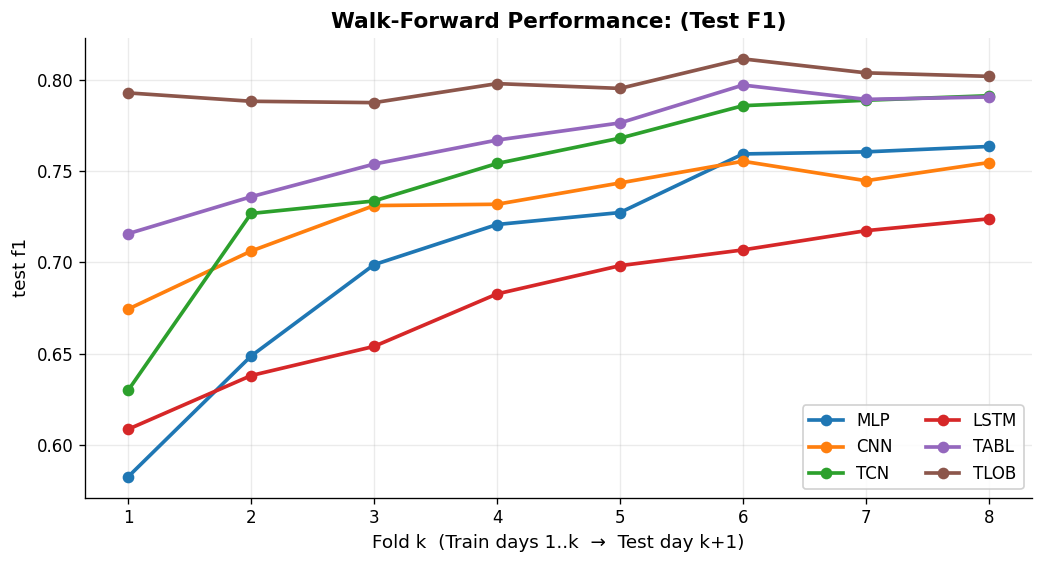

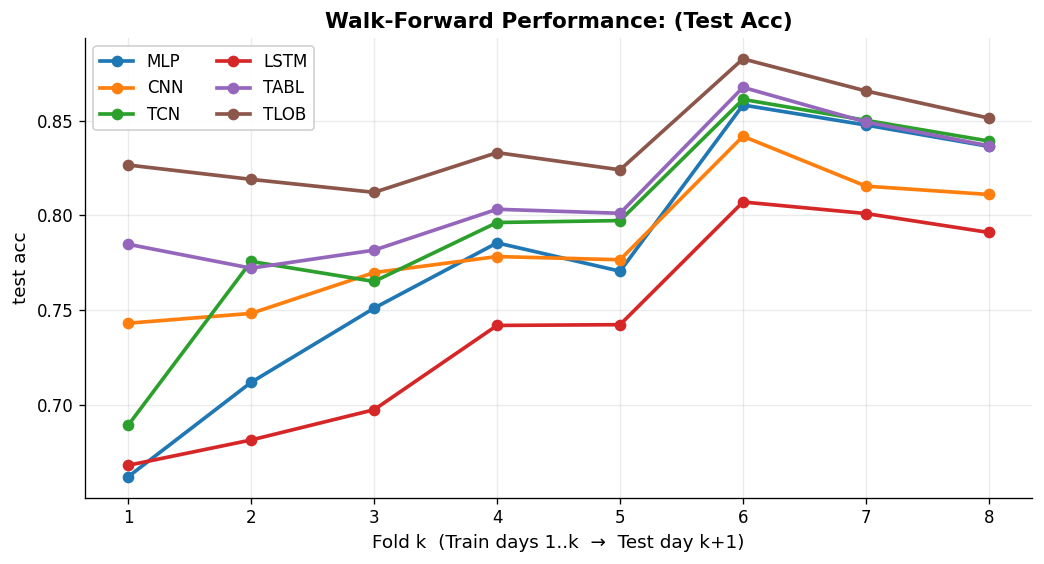

In [193]:
def plot_walk_forward(
    results_dict: Dict[str, List[Dict[str, Any]]],
    metric: str = "test_f1",
    title: Optional[str] = None,
    figsize: Tuple[float, float] = (8.8, 4.8),
) -> None:
    """
    Plot walk-forward cross-validation results across folds.

    Visualizes how each model's performance evolves as more training
    data becomes available (expanding window approach).

    Args:
        results_dict: Dictionary mapping model names to their fold results.
            Each result should contain 'fold' and the specified metric.
        metric: Metric key to plot (e.g., 'test_f1', 'test_acc').
        title: Custom plot title. Auto-generated if None.
        figsize: Figure size as (width, height).
    """

    plt.figure(figsize=figsize)
    
    for model_name, fold_results in results_dict.items():
        folds = [r["fold"] for r in fold_results]
        vals  = [r[metric] for r in fold_results]
        plt.plot(folds, vals, marker="o", label=model_name) 

    # Configure axes
    plt.xticks(range(1, max(folds) + 1))
    plt.xlabel("Fold k  (Train days 1..k  →  Test day k+1)")
    plt.ylabel(metric.replace("_", " "))
    
    if title is None:
        metric_display = metric.replace("_", " ").title()
        title = f"Walk-Forward Performance: ({metric_display})"

    plt.title(title)
    
    plt.legend(ncol=2, loc="best")
    plt.tight_layout()
    plt.show()

# Plot results
plot_walk_forward(results_dict, metric="test_f1")
plot_walk_forward(results_dict, metric="test_acc")


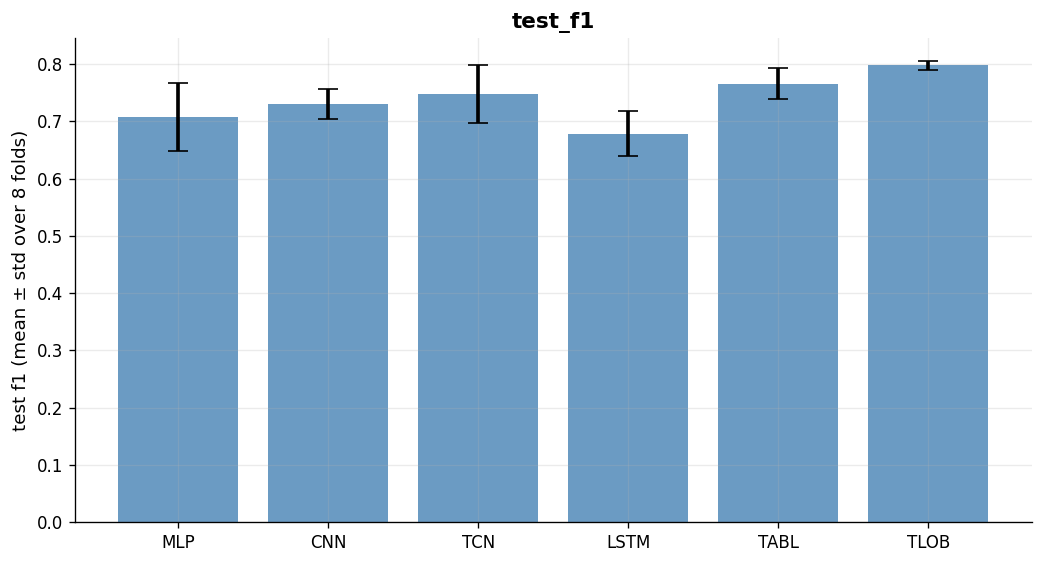

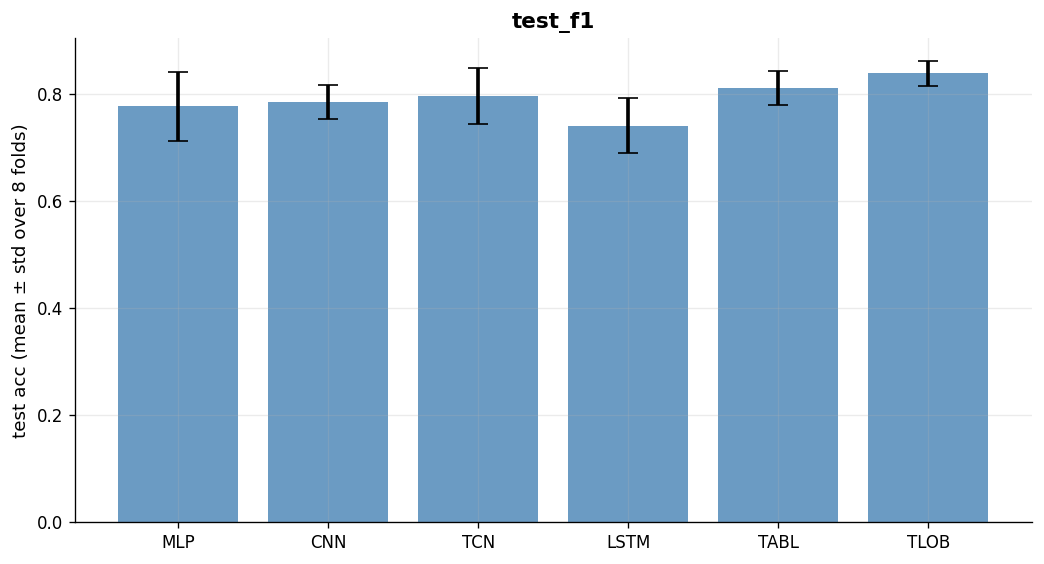

In [194]:
def bar_mean_std(
    results_dict: Dict[str, List[Dict[str, Any]]], 
    metric : str ="test_f1",
    title: str = "test_f1",
    figsize: Tuple[int, int] = (8.8, 4.8),
    capsize: int = 6,
) -> None:
    """
    Plot bar chart comparing model performance with error bars.
    
    Shows mean and standard deviation of the specified metric
    across all folds for each model.
    
    Args:
        results_dict: Dictionary mapping model names to their fold results.
        metric: Metric key to compare (e.g., 'test_f1', 'test_acc').
        title: Custom plot title. Auto-generated if None.
        figsize: Figure size as (width, height).
        capsize: Size of error bar caps.
    """
    model_names = list(results_dict.keys())
    num_folds = len(results_dict[model_names[0]])

    # Compute statistics for each model
    means = []
    stds  = []

    for name in model_names:
        values = np.array([r[metric] for r in results_dict[name]])
        means.append(values.mean())
        stds.append(values.std(ddof=0))
    
    # Create bar plot
    x_positions = np.arange(len(model_names))
    plt.figure(figsize=figsize)
    plt.bar(x_positions, means, yerr=stds, capsize=capsize, color="steelblue", alpha=0.8)
    
    # Configure axes
    plt.xticks(x_positions, model_names, rotation=0)

    metric_display = metric.replace("_", " ")
    plt.ylabel(f"{metric_display} (mean ± std over {num_folds} folds)")
    
    # Set title
    if title is None:
        title = f"Model comparison: {metric_display}"

    plt.title(title)
    
    plt.tight_layout()
    plt.show()

# Compare models
bar_mean_std(results_dict, metric="test_f1")
bar_mean_std(results_dict, metric="test_acc")



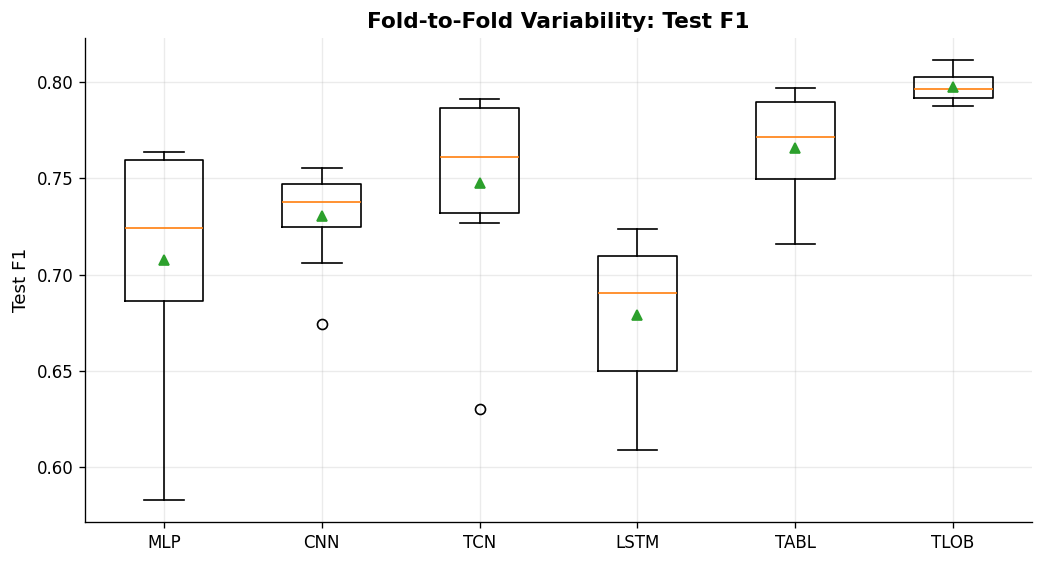

In [195]:
def plot_metric_distribution(
    results_dict: Dict[str, List[Dict[str, Any]]],
    metric: str = "test_f1",
    title: Optional[str] = None,
    figsize: tuple = (8.8, 4.8),
    show_means: bool = True,
) -> None:
    """
    Plot boxplot showing metric distribution across folds for each model.
    Visualizes fold-to-fold variability to assess model stability.
    Args:
        results_dict: Dictionary mapping model names to their fold results.
        metric: Metric key to visualize (e.g., 'test_f1', 'test_acc').
        title: Custom plot title. Auto-generated if None.
        figsize: Figure size as (width, height).
        show_means: Whether to show mean markers on boxplots.
    Example:
        >>> results = {"MLP": mlp_results, "TABL": tabl_results}
        >>> plot_metric_distribution(results, metric="test_f1")
    """
    model_names = list(results_dict.keys())

    # Extract metric values for each model
    data = [
        [r[metric] for r in results_dict[name]]
        for name in model_names
    ]

    # Create boxplot
    plt.figure(figsize=figsize)
    plt.boxplot(data, tick_labels=model_names, showmeans=show_means)

    # Configure axes
    metric_display = metric.replace("_", " ").title()
    plt.ylabel(metric_display)

    # Set title
    if title is None:
        title = f"Fold-to-Fold Variability: {metric_display}"

    plt.title(title)

    plt.tight_layout()
    plt.show()

# Plot metric distributions
plot_metric_distribution(results_dict, metric="test_f1")

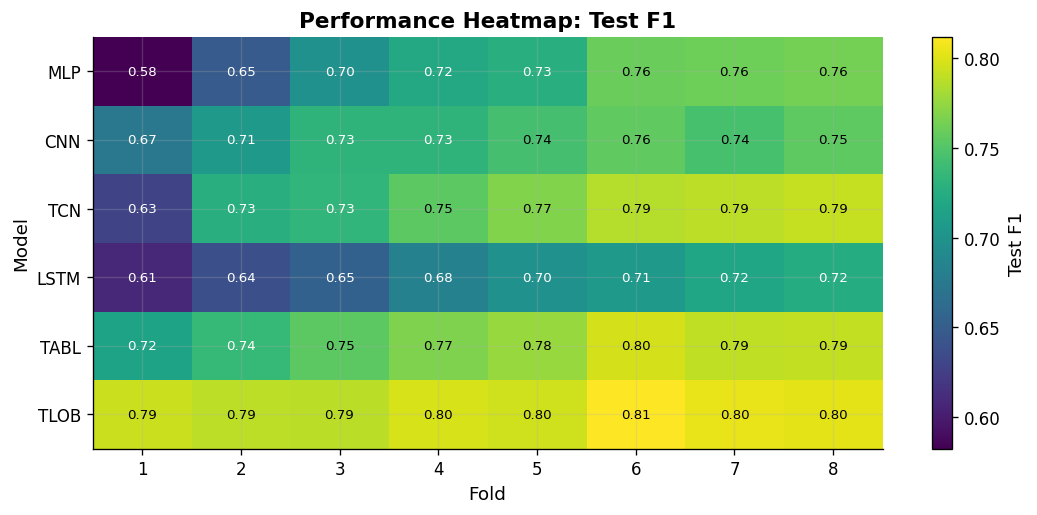

In [196]:
def plot_performance_heatmap(
    results_dict: Dict[str, List[Dict[str, Any]]],
    metric: str = "test_f1",
    title: Optional[str] = None,
    figsize: tuple = (9.2, 4.4),
    cmap: str = "viridis",
    annotate: bool = True,
) -> None:
    """
    Plot heatmap of model performance across folds.
    Visualizes the metric value for each model-fold combination,
    useful for identifying patterns in model behavior across folds.
    Args:
        results_dict: Dictionary mapping model names to their fold results.
        metric: Metric key to visualize (e.g., 'test_f1', 'test_acc').
        title: Custom plot title. Auto-generated if None.
        figsize: Figure size as (width, height).
        cmap: Colormap for the heatmap.
        annotate: Whether to show values in cells.
    Example:
        >>> results = {"MLP": mlp_results, "TABL": tabl_results}
        >>> plot_performance_heatmap(results, metric="test_f1")
    """
    model_names = list(results_dict.keys())
    num_folds = len(results_dict[model_names[0]])

    # Build matrix: (num_models, num_folds)
    matrix = np.array([
        [r[metric] for r in results_dict[name]]
        for name in model_names
    ])

    # Create heatmap
    plt.figure(figsize=figsize)
    im = plt.imshow(matrix, aspect="auto", cmap=cmap)

    metric_display = metric.replace("_", " ").title()
    plt.colorbar(im, label=metric_display)

    # Add cell annotations
    if annotate:
        for i in range(len(model_names)):
            for j in range(num_folds):
                value = matrix[i, j]
                text_color = "white" if value < matrix.mean() else "black"
                plt.text(j, i, f"{value:.2f}", ha="center", va="center", color=text_color, fontsize=8)
    
    # Configure axes
    plt.yticks(range(len(model_names)), model_names)
    plt.xticks(range(num_folds), range(1, num_folds + 1))
    plt.xlabel("Fold")
    plt.ylabel("Model")
    
    # Set title
    if title is None:
        title = f"Performance Heatmap: {metric_display}"
    
    plt.title(title)
    
    plt.tight_layout()
    plt.show()

# Plot heatmap
plot_performance_heatmap(results_dict, metric="test_f1")

In [197]:
def plot_confusion_matrix(
    results: List[Dict[str, Any]],
    title: str = "Confusion Matrix",
    normalize: Optional[Literal["true"]] = None,
    annotate: bool = True,
    figsize: tuple = (6.2, 5.4),
    cmap: str = "YlGnBu",
) -> None:
    """
    Plot confusion matrix from cross-validation results.
    Aggregates predictions from all folds and displays the confusion matrix
    as a heatmap with optional normalization and cell annotations.
    Args:
        results: List of fold result dictionaries containing 'y_true' and 'y_pred'.
        title: Plot title.
        normalize: Normalization mode:
            - None: Show raw counts.
            - "true": Normalize by true class (rows sum to 1).
        annotate: Whether to show values in cells.
        figsize: Figure size as (width, height).
        cmap: Colormap for the heatmap.
    Example:
        >>> plot_confusion_matrix(mlp_results, title="MLP Confusion Matrix")
        >>> plot_confusion_matrix(mlp_results, normalize="true")  # Show percentages
    """
    # Aggregate predictions from all folds
    y_true = np.concatenate([r["y_true"] for r in results])
    y_pred = np.concatenate([r["y_pred"] for r in results])

    # Compute confusion matrix
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

    # Normalize if requested
    if normalize is None:
        cm_display = cm.astype(float)
        colorbar_label = "Count"
        value_format = "d"

    elif normalize == "true":
        row_sums = cm.sum(axis=1, keepdims=True)
        cm_display = cm.astype(float) / np.maximum(row_sums, 1)
        colorbar_label = "Ratio (per true class)"
        value_format = ".2f"

    else:
        raise ValueError(f'normalize must be "true" or None, got {normalize}')

    # Create figure
    fig, ax = plt.subplots(figsize=figsize)

    # Plot heatmap
    vmin, vmax = (0.0, 1.0) if normalize == "true" else (None, None)
    im = ax.imshow(cm_display, cmap=cmap, vmin=vmin, vmax=vmax, aspect="equal")

    # Add colorbar
    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(colorbar_label)

    CLASS_LABELS = [0, 1, 2]
    # Configure axes
    num_classes = len(CLASS_LABELS)
    ax.set_xticks(range(num_classes))
    ax.set_yticks(range(num_classes))
    ax.set_xticklabels(CLASS_LABELS)
    ax.set_yticklabels(CLASS_LABELS)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)

    # Add grid lines between cells
    ax.set_xticks(np.arange(-0.5, num_classes, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, num_classes, 1), minor=True)
    ax.grid(which="minor", linestyle="-", linewidth=1, alpha=0.25)
    ax.tick_params(which="minor", bottom=False, left=False)

    # Add cell annotations
    if annotate:
        threshold = (cm_display.max() + cm_display.min()) / 2.0
        
        for i in range(num_classes):
            for j in range(num_classes):
                value = cm_display[i, j]
                
                # Format value based on normalization
                if normalize is None:
                    text = f"{int(value):d}"
                else:
                    text = f"{value:.2f}"
                
                # Choose text color for readability
                text_color = "white" if value > threshold else "black"
                ax.text(j, i, text, ha="center", va="center", color=text_color, fontsize=11)

    fig.tight_layout()
    plt.show()


Confusion Matrix: MLP


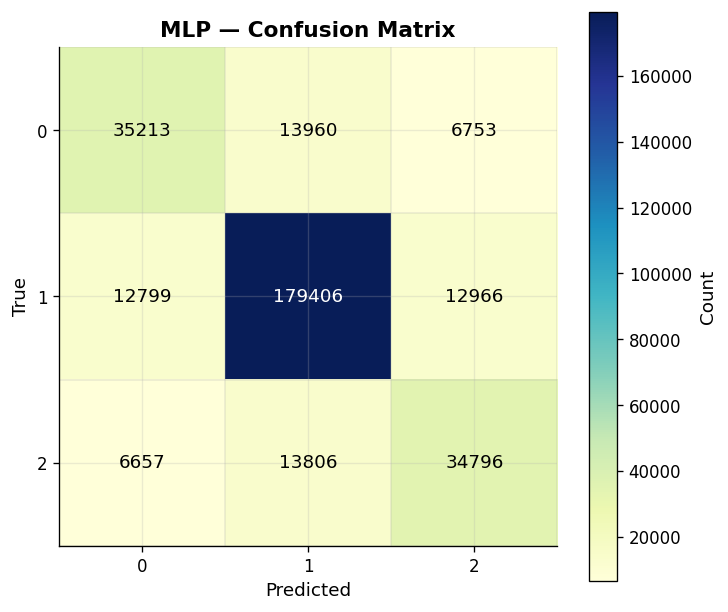

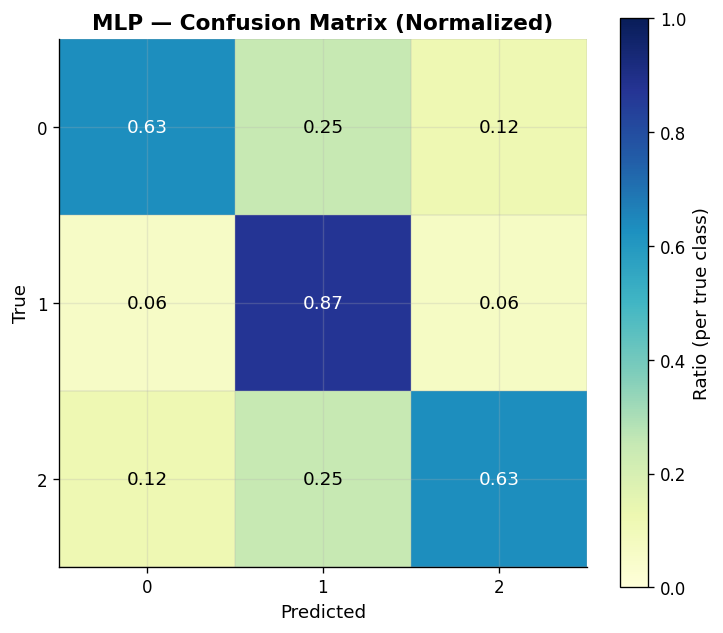


Confusion Matrix: CNN


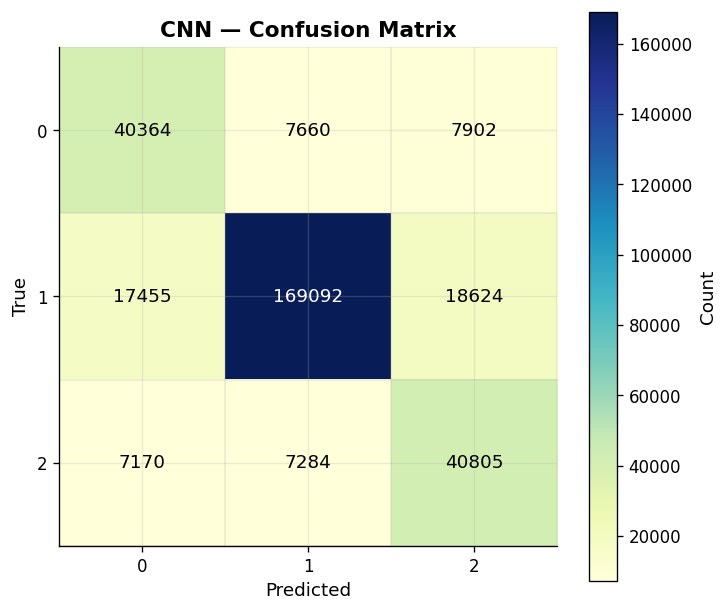

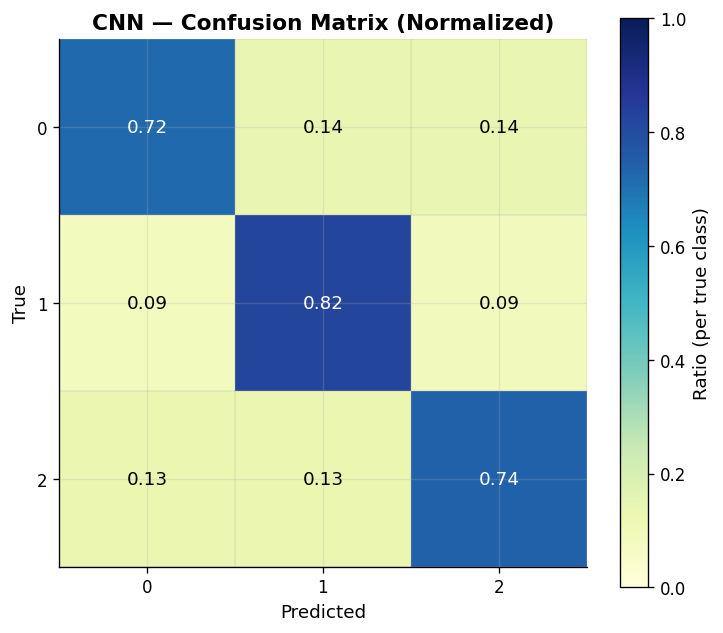


Confusion Matrix: TCN


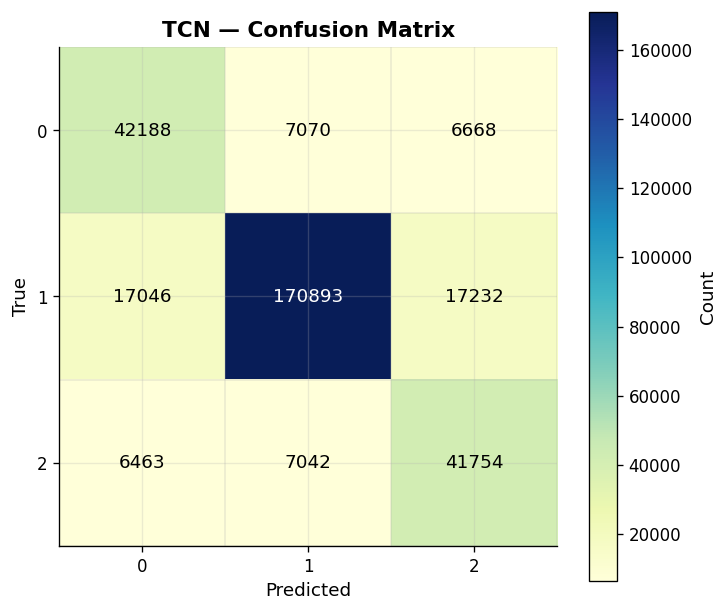

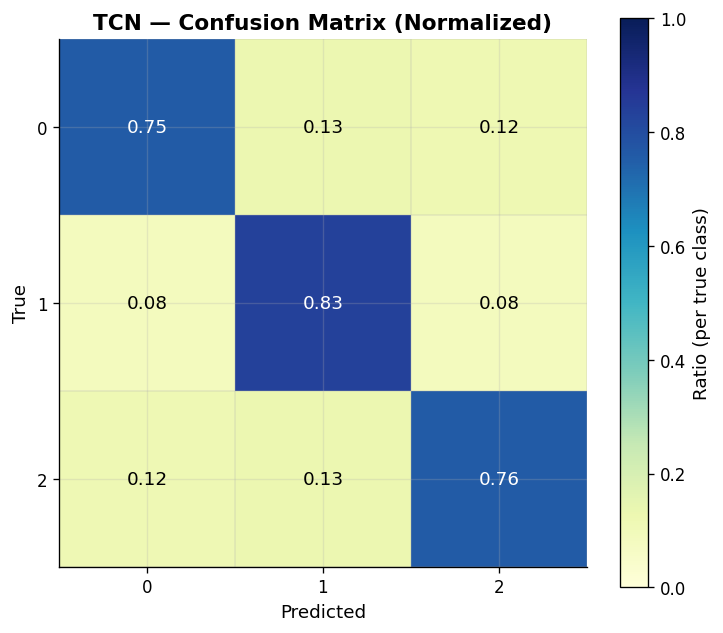


Confusion Matrix: LSTM


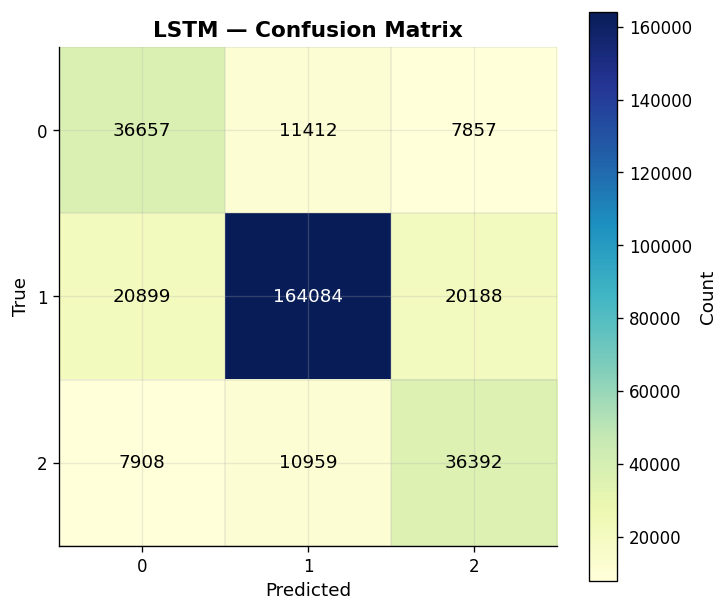

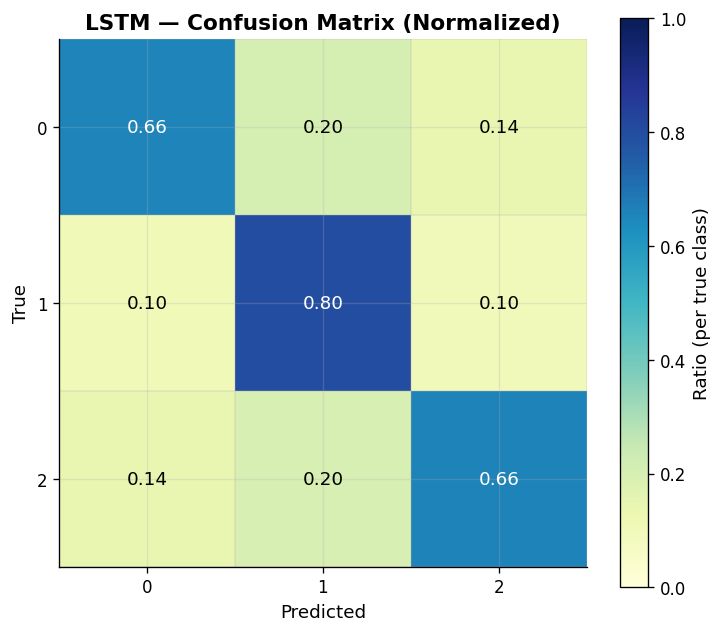


Confusion Matrix: TABL


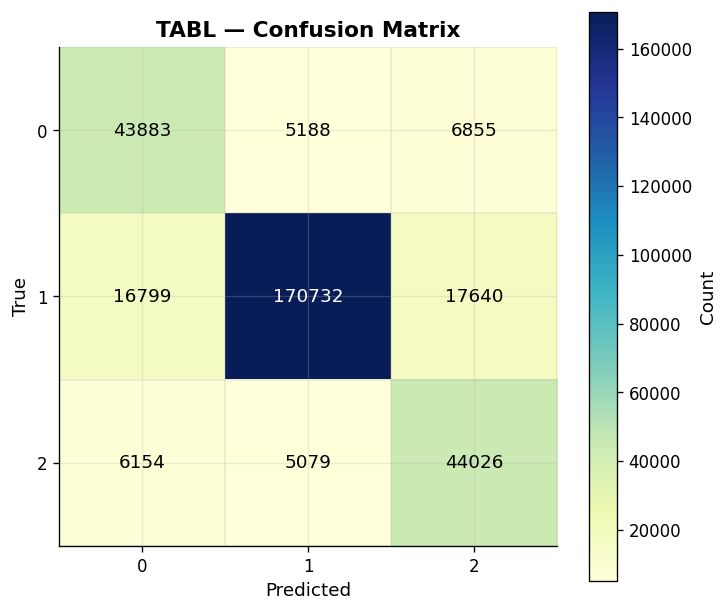

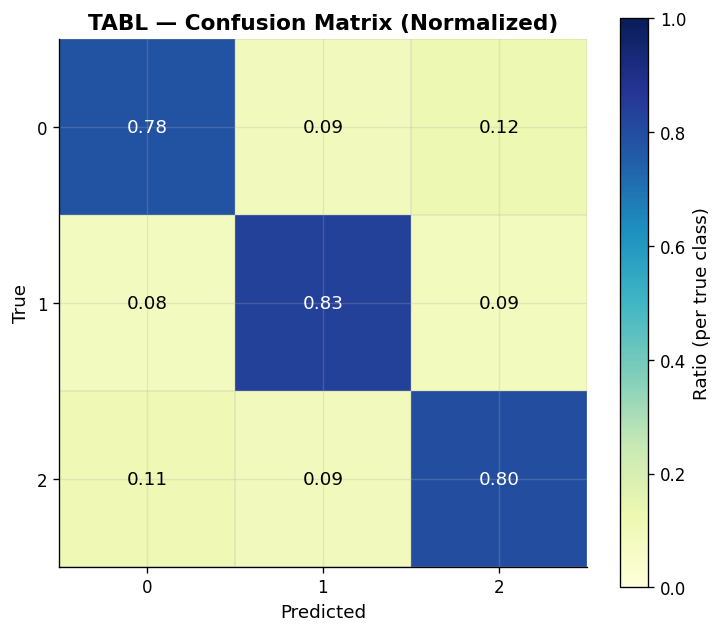


Confusion Matrix: TLOB


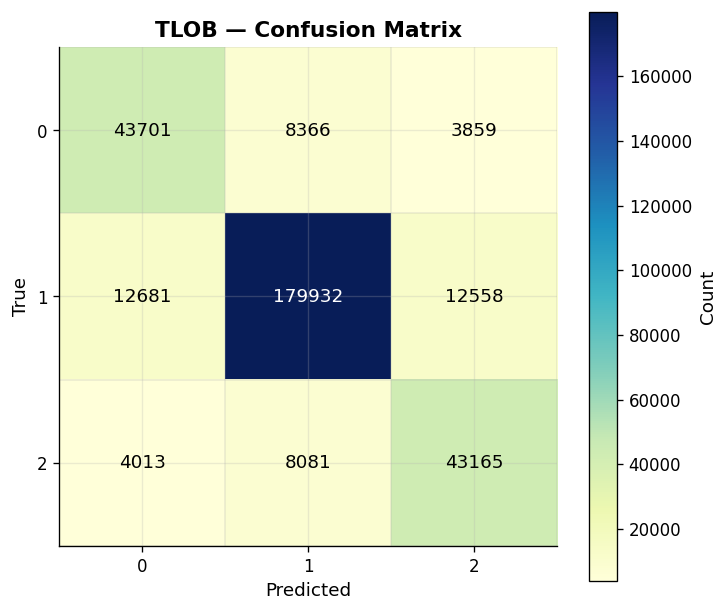

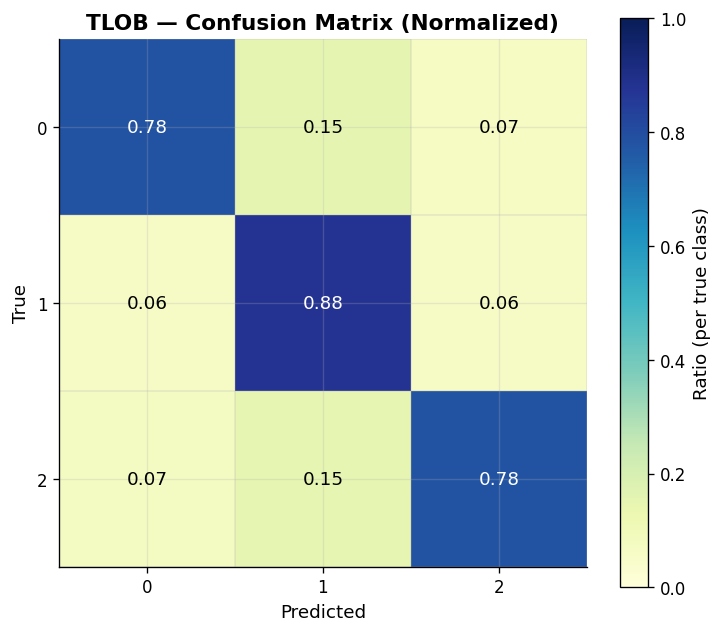

In [198]:
# Plot confusion matrices for all models
for model_name, results in results_dict.items():
    print(f"\nConfusion Matrix: {model_name}")
    
    # Raw counts
    plot_confusion_matrix(
        results,
        title=f"{model_name} — Confusion Matrix",
        normalize=None,
        annotate=True,
    )
    
    # Normalized by true class
    plot_confusion_matrix(
        results,
        title=f"{model_name} — Confusion Matrix (Normalized)",
        normalize="true",
        annotate=True,
    )